# Fusión de Datos v5 · Calidad y Preprocesamiento
**Equipo:** Calidad de Datos (Carlo Kiliano Ferrera, José Julian Pérez, Aldo Sebastián Altamirano)
**Curso:** Calidad y Preprocesamiento de Datos · Licenciatura en Ciencia de Datos · IIMAS UNAM CU · 2026‑2
**Framework:** DAMA‑DMBOK · Fase *Improve* (modelo canónico) y entrada a *Analyze*

---

## Cambios respecto a `Fusion_v4` — preparando `analisis.ipynb`

| # | Cambio | Motivo |
|---|---|---|
| 1 | **Carga de `plantas_cdmx.csv`** desde la limpieza (faltaba en v4) | El README pide "distancia a planta potabilizadora más cercana" como feature del XGBoost |
| 2 | **Asignación KNN haversine** colonia → planta más cercana | Genera `dist_planta_km` y `planta_cercana_id` por colonia |
| 3 | **Tabla maestra `plantas_potabilizadoras.csv`** exportada | Para el dashboard (capa adicional sobre el mapa) |
| 4 | **`maestra_colonia_semestre.csv`** (nueva) | El README pide "fugas en próximos 6 meses" como target. Granularidad anual destruye la mitad de la señal y hace imposible el split temporal |
| 5 | **Proxy `antiguedad_red_proxy`** | El README pide "antigüedad de la red" como feature; INEGI no publica año de urbanización por colonia. Proxy: combina densidad_pob, pct_drenaje, % aguadv |
| 6 | **`vulnerabilidad_sanitaria` (IVS) nuevo campo** | El README distingue: IVH (4 dimensiones) ≠ IVS (2 dimensiones: morbilidad + pobreza). El Score de Intervención usa IVS, no IVH |
| 7 | **`maestra_colonia.csv` cierra con campo `score_intervencion_base`** | Pre‑calcula `IVS × n_fugas_total` como punto de partida; `analisis.ipynb` lo refinará con el riesgo predicho |

## Limitaciones documentadas (no resueltas en este notebook, requieren acción del equipo)

| Limitación | Impacto | Mitigación posible |
|---|---|---|
| SACMEX histórico 2018-2021 ausente | El split train 2018-22 / val 2023 / test 2024 del README no es posible | (A) Descargar histórico de datos.cdmx.gob.mx y re-ejecutar limpieza, **o** (B) adaptar split a semestres dentro de 2022-24 |
| Sin shapefile de colonias | Mapas coropléticos reales imposibles | Descargar shapefile SEDUVI; `analisis.ipynb` puede usar mapas de puntos como sustituto aceptable |
| Sin precipitación mensual | El XGBoost no puede aprovechar estacionalidad climática | Si se requiere, descargar CLICOM/SMN en `analisis.ipynb`. Por ahora usamos promedio CDMX (≈ 800 mm/año) como constante |

## Cambios mantenidos respecto a v4

| # | Cambio | Motivo |
|---|---|---|
| 1 | Granularidad principal: colonia | Dashboard ciudadano + modelo predictivo |
| 2 | Re‑parseo de `fecha_realizacion` desde serial Excel | Bug fix v3→v4 |
| 3 | Morbilidad estimada por factor de riesgo | Bug fix v3→v4 |
| 4 | Record-linkage ANTES de territorios | Bug fix v2→v3 |
| 5 | IVH con `log(1+x)` antes de min-max | Bug fix v2→v3 |
| 6 | Pesos del IVH redistribuidos cuando un componente es constante | Bug fix v2→v3 |

## Decisiones declaradas en v5

| # | Decisión | Valor |
|---|---|---|
| 1 | Universo de colonias | SEPOMEX (1 503) ∪ huérfanas SACMEX no resueltas (~111) |
| 2 | Centroide cuando no hay reportes SACMEX | Centroide de la alcaldía (mediana) |
| 3 | Pobreza CONEVAL → colonia | Distribución uniforme dentro de alcaldía |
| 4 | Demografía INEGI → colonia | Distribución por peso uniforme dentro de alcaldía |
| 5 | Calidad agua local → colonia | KNN nearest sitio `cdmx_local` (haversine) |
| 6 | Calidad agua sistémica → colonia | Peso uniforme |
| 7 | Morbilidad SSA → colonia | Factor de riesgo (pobreza + sin_agua + sin_drenaje) × tasa estatal |
| 8 | Fugas SACMEX → colonia | Agregación directa por `id_colonia` post-linkage |
| 9 | **Plantas potabilizadoras → colonia** | **KNN haversine, distancia en km** |
| 10 | **Antigüedad red → colonia** | **Proxy: combina densidad pob + falta drenaje + falta agua entubada** |
| 11 | Threshold fuzzy match | ≥ 85 = auto, 70-84 = candidato |
| 12 | Normalización IVH | `log(1+x)` antes de min-max para fugas y calidad |
| 13 | **IVS = 0.5 × pobreza_norm + 0.5 × morbi_norm** | Definición del README para el Score de Intervención |

## Estructura

0. Configuración del entorno
1. Funciones reutilizables
2. Carga e integridad de los CSVs limpios
3. Record-linkage SACMEX↔SEPOMEX (pre-cómputo)
4. Construcción de tablas maestras dimensionales
   * 4.7 **Nueva: `plantas_potabilizadoras` con clasificación**
5. Distribución a granularidad colonia
   * 5.5 **Nueva: distancia a planta potabilizadora**
   * 5.6 **Nueva: proxy de antigüedad de red**
6. Tabla maestra colonia (snapshot estado actual + IVS + score base)
7. Tabla maestra colonia × año (anual, mantiene compatibilidad)
8. **Nueva: Tabla maestra colonia × semestre** (target del XGBoost)
9. Índice de Vulnerabilidad Hídrica (IVH) y Sanitaria (IVS)
10. Verificación post-fusión
11. Export del modelo canónico
12. Conclusiones

## 1. Configuración del entorno

In [2]:
# Instalación de dependencias (descomentar si es la primera vez)
# !pip install pandas numpy rapidfuzz scipy matplotlib seaborn

In [3]:
import os
import re
import json
import warnings
import unicodedata
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

try:
    from rapidfuzz import fuzz, process as rf_process
    HAS_RAPIDFUZZ = True
except ImportError:
    HAS_RAPIDFUZZ = False
    from difflib import SequenceMatcher
    print("⚠️ rapidfuzz no instalado; se usa difflib (más lento). pip install rapidfuzz")

try:
    from scipy.spatial import cKDTree
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    print("⚠️ scipy no instalado; KNN será O(n*m). pip install scipy para acelerar")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

### 1.1 Raíz del proyecto y rutas

In [4]:
def get_project_root(marker: str = "README.md") -> Path:
    """Sube el árbol de directorios hasta hallar el archivo `marker`."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del proyecto.")

PROJECT_ROOT   = get_project_root()
DATOS_LIMPIOS  = PROJECT_ROOT / "datos" / "datos_limpios"
DATOS_MAESTROS = PROJECT_ROOT / "datos" / "datos_maestros"
DATOS_MAESTROS.mkdir(parents=True, exist_ok=True)

print(f"📂 PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"📂 DATOS_LIMPIOS  : {DATOS_LIMPIOS}")
print(f"📂 DATOS_MAESTROS : {DATOS_MAESTROS}")
assert DATOS_LIMPIOS.exists(), "Falta limpieza."

RUTAS_IN = {
    "morbilidad":    DATOS_LIMPIOS / "morbilidad_cdmx_limpio.csv",
    "inegi":         DATOS_LIMPIOS / "inegi_cdmx_limpio.csv",
    "coneval":       DATOS_LIMPIOS / "coneval_cdmx_limpio.csv",
    "sepomex":       DATOS_LIMPIOS / "sepomex_cdmx_limpio.csv",
    "sacmex":        DATOS_LIMPIOS / "sacmex_cdmx_limpio.csv",
    "conagua_sit":   DATOS_LIMPIOS / "conagua_sitios_limpio.csv",
    "conagua_res":   DATOS_LIMPIOS / "conagua_resultados_cdmx_limpio.csv",
    "alcaldias":     DATOS_LIMPIOS / "catalogo_alcaldias_cdmx.csv",
    # v5: plantas potabilizadoras (extraídas en limpieza desde el PDF nacional)
    "plantas":       PROJECT_ROOT / "datos" / "datos_crudos" / "plantas_cdmx.csv",
}

RUTAS_OUT = {
    "territorios":             DATOS_MAESTROS / "territorios_cdmx.csv",
    "sociodemografia":         DATOS_MAESTROS / "sociodemografia_alcaldia.csv",
    "morbilidad":              DATOS_MAESTROS / "morbilidad_cdmx.csv",
    "sitios_monitoreo":        DATOS_MAESTROS / "sitios_monitoreo.csv",
    "calidad_agua":            DATOS_MAESTROS / "calidad_agua.csv",
    "incidentes_fugas":        DATOS_MAESTROS / "incidentes_fugas.csv",
    "plantas_potabilizadoras": DATOS_MAESTROS / "plantas_potabilizadoras.csv",  # v5
    "maestra_colonia":         DATOS_MAESTROS / "maestra_colonia.csv",
    "maestra_colonia_anio":    DATOS_MAESTROS / "maestra_colonia_anio.csv",
    "maestra_colonia_semestre":DATOS_MAESTROS / "maestra_colonia_semestre.csv",  # v5
    "vulnerabilidad_hidrica":  DATOS_MAESTROS / "vulnerabilidad_hidrica_colonia.csv",
    "log_fusion":              DATOS_MAESTROS / "_log_fusion.json",
    "linkage_huerfanos":       DATOS_MAESTROS / "_linkage_sacmex_huerfanos.csv",
}

📂 PROJECT_ROOT   : c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos
📂 DATOS_LIMPIOS  : c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_limpios
📂 DATOS_MAESTROS : c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_maestros


### 1.2 Constantes globales

In [5]:
# Threshold fuzzy matching
FUZZY_AUTO       = 85
FUZZY_CANDIDATO  = 70

# Año de referencia para "estado actual"
ANIO_REFERENCIA = 2024  # se usa para snapshot de fugas

# Umbrales NOM-127 (heredados del perfilado/limpieza)
NOM_127 = {
    "as_tot":         {"limite": 0.010, "param": "Arsénico"},
    "pb_tot":         {"limite": 0.010, "param": "Plomo"},
    "hg_tot":         {"limite": 0.006, "param": "Mercurio"},
    "cd_tot":         {"limite": 0.005, "param": "Cadmio"},
    "fluoruros_tot":  {"limite": 1.500, "param": "Fluoruros"},
    "n_no3":          {"limite": 10.00, "param": "Nitratos"},
    "e_coli":         {"limite": 0.000, "param": "E. coli"},
    "coli_fec":       {"limite": 0.000, "param": "Coliformes fecales"},
}

# Pesos del IVH (suma = 1.0)
PESOS_IVH = {
    "pobreza":          0.40,
    "calidad_agua":     0.25,
    "fugas_per_capita": 0.25,
    "morbilidad":       0.10,
}
assert abs(sum(PESOS_IVH.values()) - 1.0) < 1e-9

LOG = defaultdict(dict)

## 2. Funciones reutilizables

Agrega a las del v1 dos funciones críticas para la granularidad colonia: `haversine_nearest` (asigna el sitio CONAGUA más cercano a cada colonia) y `distribuir_uniforme_colonia` (reparte una métrica de alcaldía a sus colonias hijas).

In [6]:
def normalizar_texto(serie: pd.Series) -> pd.Series:
    return (serie.fillna("").astype(str)
            .str.normalize("NFKD")
            .str.encode("ascii", errors="ignore")
            .str.decode("utf-8")
            .str.upper().str.strip())


def merge_auditado(left, right, *, on, how="left", left_label="izq", right_label="der"):
    n_left, n_right = len(left), len(right)
    out = left.merge(right, on=on, how=how)
    n_out = len(out)
    inflado = (n_out > n_left) and (how in ("left", "inner"))
    flag = "⚠️" if inflado else "✅"
    print(f"  {flag} merge {how:<5} on {on}  |  {left_label}={n_left:,}  {right_label}={n_right:,}  →  out={n_out:,}")
    if inflado:
        print(f"     ↳ left ganó {n_out - n_left:,} filas (right tiene duplicados en la clave)")
    return out


def fuzzy_match_uno_a_uno(consultas, universo, threshold_auto=FUZZY_AUTO, threshold_cand=FUZZY_CANDIDATO):
    """Para cada string en `consultas`, busca su mejor match en `universo`."""
    resultados = []
    universo_unique = list(dict.fromkeys(universo))
    for q in consultas:
        if HAS_RAPIDFUZZ:
            match = rf_process.extractOne(q, universo_unique, scorer=fuzz.token_set_ratio)
            if match is None:
                resultados.append({"consulta": q, "match": None, "score": 0, "decision": "no_match"})
                continue
            best, score, _idx = match
        else:
            mejor_score, mejor = 0, None
            for u in universo_unique:
                s = SequenceMatcher(None, q, u).ratio() * 100
                if s > mejor_score:
                    mejor_score, mejor = s, u
            best, score = mejor, int(mejor_score)
        decision = ("auto" if score >= threshold_auto
                    else "candidato" if score >= threshold_cand
                    else "no_match")
        resultados.append({"consulta": q, "match": best, "score": int(score), "decision": decision})
    return pd.DataFrame(resultados)


def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia haversine entre arrays de coordenadas (km)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def parsear_fecha_excel(serie):
    """Convierte una columna que puede estar en serial date de Excel a datetime.

    Casos contemplados:
    - int como 44797 → 2022-08-24 (serial Excel desde 1899-12-30)
    - string '44797' → idem
    - string '2022-08-24' → datetime estándar
    - NaN/empty → NaT

    Justificación: la columna FECHA REALIZACIÓN del CONAGUA llega como serial Excel
    si la limpieza la lee con pd.read_csv y el archivo origen es .xlsx convertido a CSV
    sin formateo de fechas. v3 produjo fechas 1970-01-01 porque interpretó los ints como ns.
    """
    s = serie.copy()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")

    # Convertir todo a string limpio
    s_str = s.astype(str).str.strip()
    mask_vacio = s_str.isin(["", "nan", "NaN", "NaT", "None"])
    out.loc[mask_vacio] = pd.NaT

    # Detectar serial Excel: cadenas que son enteros entre 1 y 80000
    # (rango razonable: 1900-01-01 = 1, 2118 ≈ 80000)
    mask_serial = (~mask_vacio) & s_str.str.match(r"^\d+(\.\d+)?$", na=False)
    if mask_serial.any():
        nums = pd.to_numeric(s_str[mask_serial], errors="coerce")
        nums_validos = nums[(nums >= 1) & (nums <= 80000)]
        if len(nums_validos) > 0:
            origen = pd.Timestamp("1899-12-30")
            fechas = origen + pd.to_timedelta(nums_validos, unit="D")
            out.loc[nums_validos.index] = fechas

    # Para los demás (strings tipo "2022-08-24"), usar pd.to_datetime estándar
    mask_pendiente = out.isna() & ~mask_vacio
    if mask_pendiente.any():
        out.loc[mask_pendiente] = pd.to_datetime(s_str[mask_pendiente], errors="coerce", dayfirst=False)

    return out


def asignar_sitio_mas_cercano(df_colonias, df_sitios, lat_col_a="centroide_lat", lon_col_a="centroide_lon",
                                lat_col_b="latitud", lon_col_b="longitud", id_b="clave_sitio"):
    """Para cada fila de `df_colonias`, asigna el `id_b` más cercano de `df_sitios`.

    Usa la proyección lat/lon → cartesiana plana (válida porque CDMX cabe en ~50km).
    Devuelve dos series: id_sitio_cercano y distancia_km.
    """
    sitios = df_sitios.dropna(subset=[lat_col_b, lon_col_b]).copy()
    colonias = df_colonias.copy()

    # Conversión aproximada lat/lon → km (cerca del ecuador 1°≈111km, cos(lat) ajusta lon)
    lat0 = sitios[lat_col_b].mean()
    factor_lon = np.cos(np.radians(lat0)) * 111.0
    factor_lat = 111.0

    sitios_xy = np.column_stack([sitios[lat_col_b].values * factor_lat,
                                  sitios[lon_col_b].values * factor_lon])
    col_xy = np.column_stack([colonias[lat_col_a].values * factor_lat,
                               colonias[lon_col_a].values * factor_lon])

    if HAS_SCIPY:
        tree = cKDTree(sitios_xy)
        dist, idx = tree.query(col_xy, k=1)
    else:
        # Fallback: O(n*m) — funciona pero es lento con n>10k
        dist = np.empty(len(col_xy))
        idx  = np.empty(len(col_xy), dtype=int)
        for i, c in enumerate(col_xy):
            d = np.sqrt(((sitios_xy - c) ** 2).sum(axis=1))
            j = np.argmin(d)
            dist[i] = d[j]
            idx[i]  = j

    sitios_arr = sitios[id_b].values
    return pd.Series(sitios_arr[idx], index=colonias.index), pd.Series(dist, index=colonias.index)


def distribuir_uniforme_colonia(df_metricas_alc, df_territorios, columnas, clave="cve_alcaldia"):
    """Replica las métricas de `df_metricas_alc` a cada colonia de su alcaldía."""
    return df_territorios.merge(df_metricas_alc[[clave] + columnas], on=clave, how="left")


def header(title: str, char: str = "="):
    print(f"\n{char*70}\n {title}\n{char*70}")

## 3. Carga de datos limpios

In [7]:
# dtypes que importa preservar (claves no pueden perder ceros a la izquierda)
df_mor = pd.read_csv(RUTAS_IN["morbilidad"],  encoding="utf-8-sig", dtype={"cve_entidad": str})
df_ine = pd.read_csv(RUTAS_IN["inegi"],       encoding="utf-8-sig",
                      dtype={"cve_alcaldia": str, "mun": str})
df_con = pd.read_csv(RUTAS_IN["coneval"],     encoding="utf-8-sig", dtype={"cve_alcaldia": str})
df_sep = pd.read_csv(RUTAS_IN["sepomex"],     encoding="utf-8-sig",
                      dtype={"cve_alcaldia": str, "cve_estado": str, "codigo_postal": str})
df_sac = pd.read_csv(RUTAS_IN["sacmex"],      encoding="utf-8-sig", dtype={"cve_alcaldia": str},
                      low_memory=False, parse_dates=["fecha_registro_incidente", "fecha_reporte"])
df_sit = pd.read_csv(RUTAS_IN["conagua_sit"], encoding="utf-8-sig", low_memory=False)
df_res = pd.read_csv(RUTAS_IN["conagua_res"], encoding="utf-8-sig", low_memory=False)
df_alc = pd.read_csv(RUTAS_IN["alcaldias"],   encoding="utf-8-sig", dtype={"cve_alcaldia": str})

# v5: plantas potabilizadoras (CSV extraído en limpieza desde el PDF nacional)
if RUTAS_IN["plantas"].exists():
    df_plantas = pd.read_csv(RUTAS_IN["plantas"], encoding="utf-8-sig", low_memory=False)
    print(f"  ✅ plantas_cdmx cargado: {df_plantas.shape}")
else:
    df_plantas = pd.DataFrame()
    print(f"  ⚠️ {RUTAS_IN['plantas'].name} no encontrado; las features de planta se omitirán")

# 🔴 BUG FIX v2 → v3: la columna `fecha_realización` viene CON tilde (snake_case respeta acentos en limpieza)
# En v2 había una versión sin tilde 100% NaN coexistiendo con la versión con tilde válida.
# v3: forzar el rename incondicional (drop sin-tilde si existe, renombrar con-tilde a sin-tilde)
if "fecha_realizacion" in df_res.columns:
    df_res = df_res.drop(columns=["fecha_realizacion"])
if "fecha_realización" in df_res.columns:
    df_res = df_res.rename(columns={"fecha_realización": "fecha_realizacion"})
    print("  🔧 Bug fix: fecha_realización (con tilde) renombrada a fecha_realizacion")

# 🔴 BUG FIX v3 → v4: las fechas vienen como serial Excel (int 44797 = 2022-08-24).
# v3 las interpretaba como nanosegundos desde 1970 → todas las fechas salían en 1970-01-01.
# v4 detecta serial Excel y aplica origen 1899-12-30 + Timedelta(days=int).
print(f"\n  📅 Parseo de fecha_realizacion (formato serial Excel)")
print(f"     Antes:  dtype={df_res['fecha_realizacion'].dtype}, "
       f"muestra={df_res['fecha_realizacion'].head(3).tolist()}")
df_res["fecha_realizacion"] = parsear_fecha_excel(df_res["fecha_realizacion"])
print(f"     Después: dtype={df_res['fecha_realizacion'].dtype}, "
       f"muestra={df_res['fecha_realizacion'].head(3).tolist()}")
n_validas = df_res["fecha_realizacion"].notna().sum()
n_total = len(df_res)
print(f"     Fechas válidas: {n_validas}/{n_total} ({100*n_validas/n_total:.1f}%)")
if n_validas > 0:
    print(f"     Rango: {df_res['fecha_realizacion'].min()}  →  {df_res['fecha_realizacion'].max()}")

df_inventario = pd.DataFrame([
    {"tabla": "morbilidad",       "filas": len(df_mor)},
    {"tabla": "inegi",            "filas": len(df_ine)},
    {"tabla": "coneval",          "filas": len(df_con)},
    {"tabla": "sepomex",          "filas": len(df_sep)},
    {"tabla": "sacmex",           "filas": len(df_sac)},
    {"tabla": "conagua_sitios",   "filas": len(df_sit)},
    {"tabla": "conagua_results",  "filas": len(df_res)},
    {"tabla": "catalogo_alcaldias","filas": len(df_alc)},
])
display(df_inventario)

  ✅ plantas_cdmx cargado: (45, 7)
  🔧 Bug fix: fecha_realización (con tilde) renombrada a fecha_realizacion

  📅 Parseo de fecha_realizacion (formato serial Excel)
     Antes:  dtype=int64, muestra=[41199, 41382, 41558]
     Después: dtype=datetime64[ns], muestra=[Timestamp('2012-10-17 00:00:00'), Timestamp('2013-04-18 00:00:00'), Timestamp('2013-10-11 00:00:00')]
     Fechas válidas: 196/196 (100.0%)
     Rango: 2012-10-17 00:00:00  →  2024-05-09 00:00:00


,tabla,filas
0,morbilidad,8
1,inegi,494
2,coneval,190
3,sepomex,1526
4,sacmex,264303
5,conagua_sitios,7756
6,conagua_results,196
7,catalogo_alcaldias,16


### 3.1 Verificación de cobertura por alcaldía

In [8]:
matriz_cob = pd.DataFrame(index=df_alc["cve_alcaldia"])
matriz_cob["nombre"]  = df_alc["nombre_oficial"].values
matriz_cob["INEGI"]   = matriz_cob.index.isin(df_ine["cve_alcaldia"].dropna()).astype(int)
matriz_cob["CONEVAL"] = matriz_cob.index.isin(df_con["cve_alcaldia"].dropna()).astype(int)
matriz_cob["SEPOMEX"] = matriz_cob.index.isin(df_sep["cve_alcaldia"].dropna()).astype(int)
matriz_cob["SACMEX"]  = matriz_cob.index.isin(df_sac["cve_alcaldia"].dropna()).astype(int)
matriz_cob["cobertura"] = matriz_cob[["INEGI","CONEVAL","SEPOMEX","SACMEX"]].sum(axis=1)
display(matriz_cob)
n_completas = (matriz_cob["cobertura"] == 4).sum()
print(f"\n  Alcaldías con cobertura 4/4: {n_completas} de 16")
assert n_completas == 16, "Cobertura incompleta — abortar"
print("  ✅ Cobertura completa: la fusión por cve_alcaldia es segura")

,nombre,INEGI,CONEVAL,SEPOMEX,SACMEX,cobertura
cve_alcaldia,,,,,,
002,Azcapotzalco,1,1,1,1,4
003,Coyoacán,1,1,1,1,4
004,Cuajimalpa de Morelos,1,1,1,1,4
005,Gustavo A. Madero,1,1,1,1,4
006,Iztacalco,1,1,1,1,4
007,Iztapalapa,1,1,1,1,4
008,La Magdalena Contreras,1,1,1,1,4
009,Milpa Alta,1,1,1,1,4
010,Álvaro Obregón,1,1,1,1,4



  Alcaldías con cobertura 4/4: 16 de 16
  ✅ Cobertura completa: la fusión por cve_alcaldia es segura


### 3.2 Record‑linkage SACMEX↔SEPOMEX (movido desde 4.6 en v2)

**Por qué se ejecuta aquí y no después.** En `Fusion_v2` el linkage estaba en la sección 4.6, después de construir `territorios_cdmx`. Esto causó un bug grave: el catálogo `territorios` incluía 341 colonias huérfanas SACMEX que **el fuzzy match SÍ resolvía** hacia un nombre SEPOMEX. Esas 341 colonias quedaban duplicadas (una con nombre SEPOMEX, otra con el SACMEX original), inflando el catálogo y produciendo métricas inconsistentes.

**Fix v3:** ejecutamos el linkage primero, generamos el mapa `(cve_alcaldia, nombre_sacmex) → nombre_canonico_sepomex`, y luego al construir territorios sólo agregamos como huérfanas las que el linkage NO pudo resolver.

In [9]:
header("3.2 Record-linkage SACMEX↔SEPOMEX (pre-cómputo)")

# 1) Identificar pares huérfanos (en SACMEX, no en SEPOMEX)
pares_sac = df_sac[["cve_alcaldia", "colonia_norm"]].drop_duplicates().dropna()
pares_sep = (df_sep[["cve_alcaldia", "nom_colonia_norm"]]
             .drop_duplicates().dropna()
             .rename(columns={"nom_colonia_norm": "colonia_norm"}))

mi_sep = pd.MultiIndex.from_frame(pares_sep[["cve_alcaldia","colonia_norm"]])
mi_sac_pairs = pd.MultiIndex.from_frame(pares_sac[["cve_alcaldia","colonia_norm"]])
mask_huerf = ~mi_sac_pairs.isin(mi_sep)
huerfanos = pares_sac[mask_huerf]
print(f"  Pares (alcaldía,colonia) en SACMEX huérfanos: {len(huerfanos):,}")

# 2) Fuzzy match por alcaldía
filas_linkage = []
for cve, sub in huerfanos.groupby("cve_alcaldia"):
    universo_alc = pares_sep.loc[pares_sep["cve_alcaldia"] == cve, "colonia_norm"].tolist()
    consultas = sub["colonia_norm"].tolist()
    if not universo_alc:
        for q in consultas:
            filas_linkage.append({"cve_alcaldia": cve, "consulta": q,
                                   "match": None, "score": 0, "decision": "no_match"})
        continue
    df_match = fuzzy_match_uno_a_uno(consultas, universo_alc)
    df_match["cve_alcaldia"] = cve
    filas_linkage.append(df_match)

linkage = pd.concat(filas_linkage, ignore_index=True) if filas_linkage else pd.DataFrame()
resumen_linkage = linkage["decision"].value_counts()
print("\n  Resumen del fuzzy matching:")
print(resumen_linkage)

# Exportar candidatos para revisión manual del equipo
candidatos = linkage[linkage["decision"].isin(["candidato","no_match"])].copy()
candidatos.to_csv(RUTAS_OUT["linkage_huerfanos"], index=False, encoding="utf-8-sig")
print(f"\n  💾 {RUTAS_OUT['linkage_huerfanos'].name} ({len(candidatos)} pares para revisión manual)")

# 3) Construir el mapa de linkage_auto: (cve_alcaldia, nombre_sacmex) → nombre_canonico_sepomex
MAPA_LINKAGE = (linkage[linkage["decision"]=="auto"]
                .set_index(["cve_alcaldia","consulta"])["match"].to_dict())
print(f"\n  Mapa de linkage automático construido: {len(MAPA_LINKAGE)} entradas")

# 4) Set de huérfanas REALES (que el linkage no resolvió)
huerfanas_no_resueltas = linkage[linkage["decision"]!="auto"][["cve_alcaldia","consulta"]].copy()
huerfanas_no_resueltas = huerfanas_no_resueltas.rename(columns={"consulta":"colonia_norm"})
print(f"  Colonias huérfanas que NO se resolvieron por fuzzy: {len(huerfanas_no_resueltas)}")
print(f"  → Estas serán las que se agreguen al catálogo extendido (con origen='sacmex_no_oficial')")


 3.2 Record-linkage SACMEX↔SEPOMEX (pre-cómputo)
  Pares (alcaldía,colonia) en SACMEX huérfanos: 454

  Resumen del fuzzy matching:
decision
auto         343
no_match      88
candidato     23
Name: count, dtype: int64

  💾 _linkage_sacmex_huerfanos.csv (111 pares para revisión manual)

  Mapa de linkage automático construido: 343 entradas
  Colonias huérfanas que NO se resolvieron por fuzzy: 111
  → Estas serán las que se agreguen al catálogo extendido (con origen='sacmex_no_oficial')


## 4. Tablas maestras dimensionales

Construimos las seis tablas dimensionales con sus claves canónicas. La diferencia clave con `Fusion_v1` es **`territorios_cdmx` extendida**: ahora incluye las 422 colonias huérfanas de SACMEX que no estaban en SEPOMEX.

### 4.1 `territorios_cdmx` — catálogo extendido

**Universo de colonias** = SEPOMEX (1 508) ∪ huérfanas SACMEX (422). Cada colonia recibe:
* `id_colonia`: clave canónica `<cve_alcaldia>_<slug_nombre>`
* `origen` ∈ {`sepomex`, `sacmex_no_oficial`} para que análisis pueda separar.
* `centroide_lat`, `centroide_lon`: mediana de coordenadas SACMEX que la reportan; si no hay reportes → centroide de la alcaldía (fallback informado).
* `n_reportes_historicos`: para usar como peso si se necesita.

In [10]:
header("4.1 territorios_cdmx (catálogo extendido SEPOMEX ∪ huérfanas NO resueltas)")

# --- Base SEPOMEX (oficial) ---
t_sep = df_sep[["cve_alcaldia", "nom_alcaldia", "nom_colonia", "nom_colonia_norm",
                 "codigo_postal"]].copy()
t_sep = (t_sep.groupby(["cve_alcaldia", "nom_alcaldia", "nom_colonia", "nom_colonia_norm"],
                         as_index=False)
              .agg(codigos_postales=("codigo_postal",
                                      lambda s: "|".join(sorted(s.dropna().unique())))))
t_sep["origen"] = "sepomex"
print(f"  Colonias en SEPOMEX (oficial): {len(t_sep):,}")

# --- Huérfanas REALES SACMEX (las que el fuzzy NO pudo resolver) ---
# 🔴 BUG FIX v2 → v3: en v2 incluíamos TODAS las que no tenían match exacto, sin considerar
# que el fuzzy resolvía 343 de ellas. Eso producía 341 colonias duplicadas en el catálogo.
# v3: usamos huerfanas_no_resueltas (calculado en sección 3.2) como universo de huérfanas.
pares_huerfanas_resueltas = (df_sac.dropna(subset=["cve_alcaldia","colonia_norm","colonia_catalogo"])
                              [["cve_alcaldia", "colonia_catalogo", "colonia_norm"]]
                              .drop_duplicates())

# Filtrar a las huérfanas que el fuzzy NO resolvió
mi_no_res = pd.MultiIndex.from_frame(huerfanas_no_resueltas[["cve_alcaldia","colonia_norm"]])
mi_phr = pd.MultiIndex.from_frame(pares_huerfanas_resueltas[["cve_alcaldia","colonia_norm"]])
mask_no_resuelta = mi_phr.isin(mi_no_res)
t_huerf = pares_huerfanas_resueltas[mask_no_resuelta].copy()

# Tomar el primer nombre catálogo SACMEX
t_huerf = (t_huerf.groupby(["cve_alcaldia", "colonia_norm"], as_index=False)
                  .agg(nom_colonia=("colonia_catalogo", "first")))
t_huerf = t_huerf.rename(columns={"colonia_norm": "nom_colonia_norm"})
t_huerf = t_huerf.merge(df_alc[["cve_alcaldia","nombre_oficial"]],
                         on="cve_alcaldia", how="left")
t_huerf = t_huerf.rename(columns={"nombre_oficial": "nom_alcaldia"})
t_huerf["codigos_postales"] = ""
t_huerf["origen"] = "sacmex_no_oficial"
t_huerf = t_huerf[["cve_alcaldia","nom_alcaldia","nom_colonia","nom_colonia_norm",
                   "codigos_postales","origen"]]
print(f"  Colonias huérfanas SACMEX no resueltas por fuzzy: {len(t_huerf):,}")
print(f"  (en v2 eran 454 inflando el catálogo; en v3 quedan ~113)")

# --- Unir ---
territorios = pd.concat([t_sep, t_huerf], ignore_index=True)
print(f"\n  Catálogo extendido v3: {len(territorios):,} colonias")


 4.1 territorios_cdmx (catálogo extendido SEPOMEX ∪ huérfanas NO resueltas)
  Colonias en SEPOMEX (oficial): 1,508
  Colonias huérfanas SACMEX no resueltas por fuzzy: 111
  (en v2 eran 454 inflando el catálogo; en v3 quedan ~113)

  Catálogo extendido v3: 1,619 colonias


In [11]:
# --- Centroide aproximado por colonia desde SACMEX (mediana, robusta a outliers) ---
centroides = (df_sac.dropna(subset=["latitud","longitud","cve_alcaldia","colonia_norm"])
              .groupby(["cve_alcaldia", "colonia_norm"], as_index=False)
              .agg(centroide_lat=("latitud", "median"),
                   centroide_lon=("longitud", "median"),
                   n_reportes_historicos=("folio_incidente", "count"))
              .rename(columns={"colonia_norm": "nom_colonia_norm"}))
print(f"  Colonias con coordenadas SACMEX: {len(centroides):,}")

territorios = merge_auditado(territorios, centroides,
                              on=["cve_alcaldia", "nom_colonia_norm"], how="left",
                              left_label="catalogo", right_label="centroides_sac")

# --- Imputar centroide para colonias sin reportes (fallback alcaldía) ---
n_sin = territorios["centroide_lat"].isna().sum()
print(f"\n  Colonias sin centroide directo: {n_sin}")

centroides_alc = (territorios.dropna(subset=["centroide_lat"])
                  .groupby("cve_alcaldia", as_index=False)
                  .agg(c_lat_alc=("centroide_lat", "median"),
                       c_lon_alc=("centroide_lon", "median")))
territorios = territorios.merge(centroides_alc, on="cve_alcaldia", how="left")
mask_sin = territorios["centroide_lat"].isna()
territorios["centroide_imputado"] = mask_sin.astype(int)
territorios.loc[mask_sin, "centroide_lat"] = territorios.loc[mask_sin, "c_lat_alc"]
territorios.loc[mask_sin, "centroide_lon"] = territorios.loc[mask_sin, "c_lon_alc"]
territorios = territorios.drop(columns=["c_lat_alc","c_lon_alc"])
territorios["n_reportes_historicos"] = territorios["n_reportes_historicos"].fillna(0).astype(int)
print(f"  Centroides imputados con fallback alcaldía: {mask_sin.sum()}")
print(f"  Colonias finales sin centroide alguno: {territorios['centroide_lat'].isna().sum()}")

  Colonias con coordenadas SACMEX: 1,600
  ✅ merge left  on ['cve_alcaldia', 'nom_colonia_norm']  |  catalogo=1,619  centroides_sac=1,600  →  out=1,619

  Colonias sin centroide directo: 362
  Centroides imputados con fallback alcaldía: 362
  Colonias finales sin centroide alguno: 0


In [12]:
# --- ID canónico de colonia ---
territorios["id_colonia"] = (
    territorios["cve_alcaldia"] + "_" +
    territorios["nom_colonia_norm"].str.replace(r"[^A-Z0-9]+", "_", regex=True).str.strip("_")
)

# Resolver duplicados (puede haber colisiones de id en huérfanas con caracteres extraños)
n_dup = territorios.duplicated(subset=["id_colonia"]).sum()
if n_dup > 0:
    print(f"  ⚠️ {n_dup} duplicados en id_colonia → se conserva la primera (oficial sobre huérfana)")
    territorios = (territorios.sort_values("origen")  # 'sacmex_no_oficial' va después de 'sepomex' alfabéticamente; preferir sepomex
                   .drop_duplicates(subset=["id_colonia"], keep="first"))

COLS_TERR = ["id_colonia", "cve_alcaldia", "nom_alcaldia", "nom_colonia", "nom_colonia_norm",
             "codigos_postales", "origen", "centroide_lat", "centroide_lon",
             "centroide_imputado", "n_reportes_historicos"]
territorios = territorios[COLS_TERR].reset_index(drop=True)
display(territorios.head())
print(f"\n  Total final: {len(territorios):,} colonias")
print(f"  Distribución por origen:")
print(territorios["origen"].value_counts())
LOG["territorios_cdmx"] = {
    "n_filas": len(territorios),
    "n_oficial": int((territorios["origen"]=="sepomex").sum()),
    "n_no_oficial": int((territorios["origen"]=="sacmex_no_oficial").sum()),
    "n_centroide_imputado": int(territorios["centroide_imputado"].sum()),
}

  ⚠️ 5 duplicados en id_colonia → se conserva la primera (oficial sobre huérfana)


,id_colonia,cve_alcaldia,nom_alcaldia,nom_colonia,nom_colonia_norm,codigos_postales,origen,centroide_lat,centroide_lon,centroide_imputado,n_reportes_historicos
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,017,Venustiano Carranza,San Juan De Aragon Ii Seccion,SAN JUAN DE ARAGON II SECCION,,sacmex_no_oficial,19.449900,-99.081300,0,1
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,007,Iztapalapa,Pueblo Sta Cruz Meyehualco,PUEBLO STA CRUZ MEYEHUALCO,,sacmex_no_oficial,19.339983,-99.042676,0,175
2,007_REFORMA_IZTACCIHUATL_SUR,007,Iztapalapa,Reforma Iztaccihuatl Sur,REFORMA IZTACCIHUATL SUR,,sacmex_no_oficial,19.376090,-99.124592,0,8
3,008_CERRO_DEL_JUDIO_AV,008,La Magdalena Contreras,Cerro Del Judio - Av,CERRO DEL JUDIO - AV,,sacmex_no_oficial,19.324100,-99.252600,0,7
4,008_CHICHICASPATL,008,La Magdalena Contreras,Chichicaspatl,CHICHICASPATL,,sacmex_no_oficial,19.275900,-99.243800,0,1



  Total final: 1,614 colonias
  Distribución por origen:
origen
sepomex              1503
sacmex_no_oficial     111
Name: count, dtype: int64


### 4.2 `sociodemografia_alcaldia`

Una fila por alcaldía. INEGI 2020 (verdad demográfica) + CONEVAL 2020 (pobreza). Esta tabla **dimensional** se conserva igual que en v1; sirve de base para distribuir métricas a colonia en la sección 5.

In [13]:
header("4.2 sociodemografia_alcaldia")

COLS_AGG_INEGI = ["pobtot", "pob0_14", "pob15_64", "pob65_mas",
                  "vivtot", "tvivparhab", "vph_aguadv", "vph_aguafv",
                  "vph_tinaco", "vph_cister", "vph_drenaj", "vph_nodren",
                  "vph_c_serv", "vph_excsa"]
agg_inegi = (df_ine.groupby("cve_alcaldia", as_index=False)[COLS_AGG_INEGI].sum())
agg_inegi = agg_inegi.rename(columns={"pobtot": "pob_inegi", "vivtot": "viviendas_inegi"})
agg_inegi["pct_aguadv"]  = (agg_inegi["vph_aguadv"]  / agg_inegi["tvivparhab"] * 100).round(2)
agg_inegi["pct_drenaje"] = (agg_inegi["vph_drenaj"]  / agg_inegi["tvivparhab"] * 100).round(2)
agg_inegi["pct_tinaco"]  = (agg_inegi["vph_tinaco"]  / agg_inegi["tvivparhab"] * 100).round(2)
agg_inegi["densidad_pob_por_vivienda"] = (agg_inegi["pob_inegi"] / agg_inegi["tvivparhab"]).round(2)

df_con_2020 = df_con[df_con["anio"] == df_con["anio"].max()].copy()
agg_coneval = (df_con_2020.groupby("cve_alcaldia", as_index=False)
               .agg(pob_coneval=("poblacion", "sum"),
                    pobreza_pct_promedio=("pobreza_porcentaje", "mean"),
                    ingreso_lpi_pct_promedio=("ingreso_inferior_a_lpi_porcentaje", "mean"),
                    carencia_calidad_espacios_pct=("carencia_calidad_espacios_vivienda_porcentaje", "mean")))
for c in ["pobreza_pct_promedio","ingreso_lpi_pct_promedio","carencia_calidad_espacios_pct"]:
    agg_coneval[c] = agg_coneval[c].round(2)

sociodemo = merge_auditado(df_alc[["cve_alcaldia", "nombre_oficial"]], agg_inegi,
                           on="cve_alcaldia", how="left",
                           left_label="catalogo", right_label="inegi_agg")
sociodemo = merge_auditado(sociodemo, agg_coneval, on="cve_alcaldia", how="left",
                           left_label="prev", right_label="coneval_agg")
sociodemo["err_pob_pct"] = ((sociodemo["pob_inegi"] - sociodemo["pob_coneval"]).abs()
                             / sociodemo["pob_inegi"] * 100).round(2)

display(sociodemo[["nombre_oficial", "pob_inegi", "pob_coneval", "err_pob_pct",
                    "pobreza_pct_promedio", "pct_aguadv", "pct_drenaje"]])
LOG["sociodemografia_alcaldia"] = {"n_filas": len(sociodemo),
                                    "n_alcaldias_discrep_pob": int((sociodemo["err_pob_pct"] > 5).sum())}


 4.2 sociodemografia_alcaldia
  ✅ merge left  on cve_alcaldia  |  catalogo=16  inegi_agg=16  →  out=16
  ✅ merge left  on cve_alcaldia  |  prev=16  coneval_agg=16  →  out=16


,nombre_oficial,pob_inegi,pob_coneval,err_pob_pct,pobreza_pct_promedio,pct_aguadv,pct_drenaje
0,Azcapotzalco,432205,404958,6.30,24.59,99.57,99.69
1,Coyoacán,614447,568912,7.41,27.50,99.76,99.72
2,Cuajimalpa de Morelos,217643,199873,8.16,31.77,99.34,99.52
3,Gustavo A. Madero,1173351,1130265,3.67,33.69,99.63,99.76
4,Iztacalco,404695,376977,6.85,25.72,99.69,99.72
5,Iztapalapa,1835486,1760382,4.09,42.87,99.59,99.77
6,La Magdalena Contreras,247580,241691,2.38,42.17,98.68,99.51
7,Milpa Alta,152538,161267,5.72,53.44,89.37,98.28
8,Álvaro Obregón,759133,726045,4.36,37.67,99.54,99.60
9,Tláhuac,392253,377745,3.70,41.50,97.60,99.50


### 4.3 `morbilidad_cdmx`

In [14]:
header("4.3 morbilidad_cdmx")

morbi = df_mor.copy()
pob_cdmx_inegi = sociodemo["pob_inegi"].sum()
print(f"  Población CDMX (INEGI 2020): {pob_cdmx_inegi:,}")
morbi["tasa_por_100k"] = (morbi["acumulado"] / pob_cdmx_inegi * 100_000).round(2)

COLS_MORBI = ["cve_diagno","des_diagno","periodo","acumulado","tasa_por_100k","totalm","totalf",
              "menores_1","de01_a_04","de05_a_09","de10_a_14","de15_a_19","de20_a_24",
              "de25_a_44","de45_a_49","de50_a_59","de60_a_64","de65_y_mas"]
morbi = morbi[COLS_MORBI].sort_values("acumulado", ascending=False).reset_index(drop=True)

display(morbi[["des_diagno","acumulado","tasa_por_100k","totalm","totalf"]])

# Tasa total estatal hidrica (la que se replica a colonia)
TASA_MORBI_ESTATAL = float(morbi["tasa_por_100k"].sum())
CASOS_MORBI_ESTATAL = int(morbi["acumulado"].sum())
print(f"\n  Tasa hidrica estatal acumulada (por 100k): {TASA_MORBI_ESTATAL:.2f}")
print(f"  Total casos hidricos 2017: {CASOS_MORBI_ESTATAL:,}")

LOG["morbilidad_cdmx"] = {"n_filas": len(morbi),
                           "casos_total": CASOS_MORBI_ESTATAL,
                           "tasa_estatal_por_100k": round(TASA_MORBI_ESTATAL,2),
                           "anio_casos": int(morbi["periodo"].iloc[0])}


 4.3 morbilidad_cdmx
  Población CDMX (INEGI 2020): 9,209,260


,des_diagno,acumulado,tasa_por_100k,totalm,totalf
0,Infecciones intestinales por otros organismos ...,449762,4883.80,207086,242676
1,Amebiasis intestinal,6621,71.90,2914,3707
2,Otras infecciones intestinales debidas a proto...,3534,38.37,1630,1904
3,Giardiasis,508,5.52,215,293
4,Fiebre tifoidea,156,1.69,78,78
5,Shigelosis,38,0.41,17,21
6,Fiebre paratifoidea,27,0.29,8,19
7,Cólera,0,0.00,0,0



  Tasa hidrica estatal acumulada (por 100k): 5001.98
  Total casos hidricos 2017: 460,646


### 4.4 `sitios_monitoreo`

In [15]:
header("4.4 sitios_monitoreo")

clasificacion_por_sitio = (df_res[["clave_sitio", "clasificacion_cdmx"]]
                            .drop_duplicates().dropna(subset=["clasificacion_cdmx"]))
n_multi = (clasificacion_por_sitio.groupby("clave_sitio").size() > 1).sum()
if n_multi > 0:
    clasificacion_por_sitio = clasificacion_por_sitio.drop_duplicates(subset=["clave_sitio"])

sitios_relevantes = df_sit[df_sit["clave_sitio"].isin(clasificacion_por_sitio["clave_sitio"])].copy()

# Asegurar coords numéricas
sitios_relevantes["latitud"]  = pd.to_numeric(sitios_relevantes["latitud"], errors="coerce")
sitios_relevantes["longitud"] = pd.to_numeric(sitios_relevantes["longitud"], errors="coerce")

sitios_master = merge_auditado(sitios_relevantes, clasificacion_por_sitio,
                                on="clave_sitio", how="left",
                                left_label="sitios", right_label="clasif")

COLS_SIT = ["clave_sitio","nombre_del_sitio","clasificacion_cdmx",
            "cuerpo_de_agua","tipo_de_cuerpo_de_agua","subtipo_cuerpo_agua",
            "estado","municipio","cuenca","acuifero",
            "latitud","longitud","es_cdmx"]
COLS_SIT = [c for c in COLS_SIT if c in sitios_master.columns]
sitios_master = sitios_master[COLS_SIT]

resumen_sub = sitios_master.groupby("clasificacion_cdmx").size().sort_values(ascending=False)
print("\n  Distribución por subsistema:")
print(resumen_sub)
display(sitios_master.head())
LOG["sitios_monitoreo"] = {"n_filas": len(sitios_master),
                            "subsistemas": resumen_sub.to_dict()}


 4.4 sitios_monitoreo
  ✅ merge left  on clave_sitio  |  sitios=24  clasif=24  →  out=24

  Distribución por subsistema:
clasificacion_cdmx
cdmx_local          20
cutzamala_rio        2
cutzamala_tuxpan     2
dtype: int64


,clave_sitio,nombre_del_sitio,clasificacion_cdmx,cuerpo_de_agua,tipo_de_cuerpo_de_agua,subtipo_cuerpo_agua,estado,municipio,cuenca,acuifero,latitud,longitud,es_cdmx
0,DLGUE1341,CUTZAMALA AGUAS ABAJO DE ALTAMIRANO,cutzamala_rio,RIO CUTZAMALA,LÓTICO,RÍO,MICHOACÁN DE OCAMPO,SAN LUCAS,RÍO MEDIO BALSAS,NaN,18.368540,-100.671690,0
1,DLGUE1343,LAS QUERENDAS (RIO CUTZAMALA),cutzamala_rio,RIO CUTZAMALA,LÓTICO,RÍO,GUERRERO,PUNGARABATO,RÍO MEDIO BALSAS,NaN,18.371503,-100.629106,0
2,DLGUE1391,LAGO DE TUXPAN 1,cutzamala_tuxpan,LAGO DE TUXPAN,LÉNTICO,LAGO,GUERRERO,IGUALA DE LA INDEPENDENCIA,RÍO MEDIO BALSAS,NaN,18.367303,-99.497460,0
3,DLGUE1392,LAGO DE TUXPAN 2,cutzamala_tuxpan,LAGO DE TUXPAN,LÉNTICO,LAGO,GUERRERO,IGUALA DE LA INDEPENDENCIA,RÍO MEDIO BALSAS,NaN,18.358193,-99.481937,0
4,OCAVM2685,SISTEMA LACUSTRE EJIDOS DE XOCHIMILCO Y SAN GR...,cdmx_local,CUERPO DE AGUA DEL HUMEDAL,LÉNTICO (HUMEDAL),LAGO,CIUDAD DE MÉXICO,XOCHIMILCO,XOCHIMILCO,NaN,19.283200,-99.079433,1


### 4.5 `calidad_agua`

Mediciones CONAGUA con flags de conformidad NOM‑127 por parámetro. **Bug fix v1:** la columna `fecha_realización` viene con tilde en el limpio (snake_case respeta acentos); ya se renombró a `fecha_realizacion` en la celda de carga.

In [16]:
header("4.5 calidad_agua")

calidad = df_res.copy()
# fecha_realizacion ya viene parseada correctamente desde la carga (sección 3); no re-parsear
calidad["anio_medicion"] = calidad["fecha_realizacion"].dt.year.fillna(calidad["año"]).astype("Int64")

flags_nom = []
for col, info in NOM_127.items():
    if col not in calidad.columns:
        continue
    flag_col = f"excede_nom_{col}"
    calidad[flag_col] = (pd.to_numeric(calidad[col], errors="coerce") > info["limite"]).astype("Int64")
    flags_nom.append(flag_col)

if flags_nom:
    calidad["excede_alguna_nom"] = (calidad[flags_nom].sum(axis=1) > 0).astype(int)
else:
    calidad["excede_alguna_nom"] = 0

resumen_calidad = (calidad.groupby("clasificacion_cdmx")
                   .agg(n_mediciones=("clave_sitio","size"),
                        pct_excede_nom=("excede_alguna_nom","mean"),
                        anio_min=("anio_medicion","min"),
                        anio_max=("anio_medicion","max"))
                   .assign(pct_excede_nom=lambda d: (d["pct_excede_nom"]*100).round(1)))
display(resumen_calidad)

LOG["calidad_agua"] = {"n_filas": len(calidad),
                        "n_mediciones_excede_nom": int(calidad["excede_alguna_nom"].sum()),
                        "params_evaluados": flags_nom}


 4.5 calidad_agua


,n_mediciones,pct_excede_nom,anio_min,anio_max
clasificacion_cdmx,,,,
cdmx_local,170,57.6,2012,2024
cutzamala_rio,22,81.8,2012,2020
cutzamala_tuxpan,4,75.0,2012,2014


### 4.6 `incidentes_fugas` (aplicación del mapa de linkage de la sección 3.2)

El record‑linkage ya se ejecutó en la sección 3.2. Aquí simplemente aplicamos `MAPA_LINKAGE` para asignar `id_colonia` canónico a cada reporte SACMEX.

In [17]:
header("4.6 incidentes_fugas (aplicación del mapa de linkage)")

incidentes = df_sac.copy()
incidentes["origen_colonia"] = "match_exacto"

# Identificar pares huérfanos (reusa mi_sep de la sección 3.2)
mi_sac_full = pd.MultiIndex.from_frame(incidentes[["cve_alcaldia","colonia_norm"]])
mask_huerf_full = ~mi_sac_full.isin(mi_sep) & incidentes["colonia_norm"].notna()
incidentes.loc[mask_huerf_full, "origen_colonia"] = "huerfano"

# Aplicar el MAPA_LINKAGE pre-calculado en sección 3.2
def _map_linkage(row):
    if row["origen_colonia"] != "huerfano":
        return row["colonia_norm"], row["origen_colonia"]
    key = (row["cve_alcaldia"], row["colonia_norm"])
    if key in MAPA_LINKAGE:
        return MAPA_LINKAGE[key], "linkage_auto"
    return row["colonia_norm"], "huerfano"

resultado = incidentes.apply(_map_linkage, axis=1, result_type="expand")
incidentes["colonia_canonica"] = resultado[0]
incidentes["origen_colonia"]   = resultado[1]

# id_colonia consistente con territorios (catálogo correctamente NO duplicado)
incidentes["id_colonia"] = (
    incidentes["cve_alcaldia"].astype(str) + "_" +
    incidentes["colonia_canonica"].fillna("").astype(str)
        .str.replace(r"[^A-Z0-9]+", "_", regex=True).str.strip("_")
)

print("\n  Distribución 'origen_colonia' tras linkage:")
print(incidentes["origen_colonia"].value_counts())


 4.6 incidentes_fugas (aplicación del mapa de linkage)

  Distribución 'origen_colonia' tras linkage:
origen_colonia
match_exacto    217043
linkage_auto     43008
huerfano          4252
Name: count, dtype: int64


In [18]:
# Subset y export
COLS_INC = ["folio_incidente","id_reporte","fecha_registro_incidente","fecha_reporte",
            "lag_dias","flag_lag_largo",
            "clasificacion","reporte","medio_recepcion",
            "alcaldia_catalogo","cve_alcaldia",
            "colonia_catalogo","colonia_canonica","id_colonia","origen_colonia",
            "latitud","longitud","flag_geo_fuera_cdmx"]
COLS_INC = [c for c in COLS_INC if c in incidentes.columns]
incidentes_master = incidentes[COLS_INC].copy()
incidentes_master["anio_reporte"] = pd.to_datetime(incidentes_master["fecha_reporte"], errors="coerce").dt.year

display(incidentes_master.head(3))
LOG["incidentes_fugas"] = {
    "n_filas": len(incidentes_master),
    "linkage": resumen_linkage.to_dict() if hasattr(resumen_linkage,"to_dict") else dict(resumen_linkage),
    "filas_linkage_auto": int((incidentes_master["origen_colonia"]=="linkage_auto").sum()),
    "filas_aun_huerfanas": int((incidentes_master["origen_colonia"]=="huerfano").sum()),
}

,folio_incidente,id_reporte,fecha_registro_incidente,fecha_reporte,lag_dias,flag_lag_largo,clasificacion,reporte,medio_recepcion,alcaldia_catalogo,cve_alcaldia,colonia_catalogo,colonia_canonica,id_colonia,origen_colonia,latitud,longitud,flag_geo_fuera_cdmx,anio_reporte
0,I-20220101-0008,R-20221204-0151,2022-01-02,2022-12-04,336.0,1,Agua Potable,Fuga,Ciudadano (Call Center),Tlalpan,012,Miguel Hidalgo 4a Seccion,MIGUEL HIDALGO 4A SECCION,012_MIGUEL_HIDALGO_4A_SECCION,match_exacto,19.273899,-99.207036,0,2022
1,I-20220101-0047,R-20220103-0332,2022-01-02,2022-01-03,1.0,0,Agua Potable,Fuga,Ciudadano (Call Center),Venustiano Carranza,017,Pensador Mexicano,PENSADOR MEXICANO,017_PENSADOR_MEXICANO,match_exacto,19.442848,-99.079031,0,2022
2,I-20220101-0055,R-20220104-0400,2022-01-02,2022-01-04,2.0,0,Agua Potable,Fuga,Ciudadano (Call Center),Iztacalco,006,Viaducto Piedad,VIADUCTO PIEDAD,006_VIADUCTO_PIEDAD,match_exacto,19.400352,-99.133973,0,2022


### 4.7 `plantas_potabilizadoras` — tabla maestra (NUEVA en v5)

Catálogo de plantas potabilizadoras de CDMX extraído por la limpieza desde el PDF
del Inventario Nacional de Plantas Potabilizadoras y de Tratamiento de Aguas
Residuales (CONAGUA 2024). El README pide explícitamente "distancia a planta
potabilizadora más cercana" como feature del XGBoost; esta tabla viabiliza esa
asignación en la sección 5.5.

Cada planta entra al catálogo con su clave, nombre, ubicación (alcaldía/municipio),
caudal y proceso de potabilización. Si la limpieza no generó coordenadas
(las del PDF venían sin lat/lon), se asigna el centroide de la alcaldía del catálogo
de territorios como ubicación aproximada.

In [19]:
header("4.7 plantas_potabilizadoras")

if len(df_plantas) == 0:
    print("  ⚠️ Sin datos de plantas; saltamos esta tabla")
    plantas_master = pd.DataFrame(columns=["id_planta","nombre","cve_alcaldia",
                                            "latitud","longitud","caudal_l_s",
                                            "proceso","origen_coords"])
else:
    print(f"  Plantas crudas: {df_plantas.shape}")
    print(f"  Columnas: {df_plantas.columns.tolist()}")

    plantas_master = df_plantas.copy()
    # snake_case
    plantas_master.columns = [c.lower().strip().replace(" ","_").replace("/","_")
                               for c in plantas_master.columns]

    # Detectar columnas relevantes (heurística: las plantas vienen del PDF con nombres variables)
    col_municipio = next((c for c in plantas_master.columns
                          if "municipio" in c or "alcald" in c or "delegacion" in c), None)
    col_nombre = next((c for c in plantas_master.columns
                        if "nombre" in c or "planta" in c.lower()), plantas_master.columns[0])
    col_caudal = next((c for c in plantas_master.columns
                        if "caudal" in c or "l_s" in c or "capacidad" in c), None)
    col_proceso = next((c for c in plantas_master.columns
                         if "proceso" in c or "tipo" in c), None)
    print(f"\n  Columnas detectadas: municipio={col_municipio}, nombre={col_nombre}, "
           f"caudal={col_caudal}, proceso={col_proceso}")

    # Asignar cve_alcaldia por normalización de texto del municipio
    if col_municipio:
        plantas_master["municipio_norm"] = normalizar_texto(plantas_master[col_municipio])
        df_alc_norm = df_alc.copy()
        df_alc_norm["nombre_norm"] = normalizar_texto(df_alc_norm["nombre_oficial"])
        plantas_master = plantas_master.merge(
            df_alc_norm[["nombre_norm","cve_alcaldia"]].rename(columns={"nombre_norm":"municipio_norm"}),
            on="municipio_norm", how="left"
        )
        plantas_master = plantas_master.drop(columns=["municipio_norm"])
    else:
        plantas_master["cve_alcaldia"] = pd.NA

    # ID canónico de planta
    plantas_master["id_planta"] = "PLANTA_" + plantas_master.index.astype(str).str.zfill(3)

    # Coordenadas: si la limpieza no las trajo, asignar centroide de la alcaldía
    if "latitud" not in plantas_master.columns:
        plantas_master["latitud"] = np.nan
        plantas_master["longitud"] = np.nan

    plantas_master["latitud"]  = pd.to_numeric(plantas_master["latitud"], errors="coerce")
    plantas_master["longitud"] = pd.to_numeric(plantas_master["longitud"], errors="coerce")

    # Centroide de alcaldía como fallback
    centroides_alc = (territorios.groupby("cve_alcaldia", as_index=False)
                      .agg(c_lat=("centroide_lat","median"),
                           c_lon=("centroide_lon","median")))
    plantas_master = plantas_master.merge(centroides_alc, on="cve_alcaldia", how="left")
    mask_sin_coords = plantas_master["latitud"].isna() | plantas_master["longitud"].isna()
    plantas_master.loc[mask_sin_coords, "latitud"]  = plantas_master.loc[mask_sin_coords, "c_lat"]
    plantas_master.loc[mask_sin_coords, "longitud"] = plantas_master.loc[mask_sin_coords, "c_lon"]
    plantas_master["origen_coords"] = np.where(mask_sin_coords, "centroide_alcaldia", "directa_pdf")
    plantas_master = plantas_master.drop(columns=["c_lat","c_lon"])

    print(f"\n  Plantas con coords directas: {(plantas_master['origen_coords']=='directa_pdf').sum()}")
    print(f"  Plantas con coords imputadas (centroide alcaldía): {mask_sin_coords.sum()}")
    print(f"  Plantas en scope CDMX: {plantas_master['cve_alcaldia'].notna().sum()} / {len(plantas_master)}")

    # Subset y export
    cols_finales = ["id_planta", col_nombre, "cve_alcaldia", "latitud", "longitud", "origen_coords"]
    if col_caudal: cols_finales.append(col_caudal)
    if col_proceso: cols_finales.append(col_proceso)
    cols_finales = [c for c in cols_finales if c in plantas_master.columns]
    plantas_master = plantas_master[cols_finales].copy()
    plantas_master = plantas_master.rename(columns={col_nombre: "nombre"})
    if col_caudal:  plantas_master = plantas_master.rename(columns={col_caudal: "caudal_l_s"})
    if col_proceso: plantas_master = plantas_master.rename(columns={col_proceso: "proceso"})

display(plantas_master.head() if len(plantas_master) else "Sin datos")
LOG["plantas_potabilizadoras"] = {
    "n_filas": len(plantas_master),
    "n_con_coords_directas": int((plantas_master.get("origen_coords")=="directa_pdf").sum()) if len(plantas_master) else 0,
    "n_con_coords_imputadas": int((plantas_master.get("origen_coords")=="centroide_alcaldia").sum()) if len(plantas_master) else 0,
}


 4.7 plantas_potabilizadoras
  Plantas crudas: (45, 7)
  Columnas: ['Municipio', 'Localidad', 'Nombre de la planta', 'Proceso', 'Capacidad instalada\n(l/s)', 'Caudal potabilizado\n(l/s)', 'Responsable de la operación de la planta']

  Columnas detectadas: municipio=municipio, nombre=nombre_de_la_planta, caudal=capacidad_instalada
(l_s), proceso=proceso

  Plantas con coords directas: 0
  Plantas con coords imputadas (centroide alcaldía): 45
  Plantas en scope CDMX: 43 / 45


,id_planta,nombre,cve_alcaldia,latitud,longitud,origen_coords,caudal_l_s,proceso
0,PLANTA_000,Trabajadores del Hierro,002,19.478668,-99.176111,centroide_alcaldia,50.0,Filtración directa
1,PLANTA_001,Deportivo Ferrería,002,19.478668,-99.176111,centroide_alcaldia,50.0,Filtración directa
2,PLANTA_002,Jardines del Pedregal 5,005,19.492428,-99.124868,centroide_alcaldia,80.0,Filtración directa
3,PLANTA_003,Panamericana,005,19.492428,-99.124868,centroide_alcaldia,50.0,Filtración directa
4,PLANTA_004,La Libertad,005,19.492428,-99.124868,centroide_alcaldia,50.0,Ósmosis inversa


## 5. Distribución a granularidad colonia

Aquí está el corazón del cambio v2. Llevamos cada métrica del proyecto a nivel `id_colonia`. Las decisiones declaradas en la portada se aplican aquí; cada columna deriva lleva su flag `*_origen` para que `analisis.ipynb` sepa cuánto confiar.

### 5.1 Demografía e infraestructura INEGI a colonia

INEGI publica a nivel localidad (494 localidades en CDMX) pero "localidad INEGI" no es lo mismo que "colonia SEPOMEX". Sin AGEBs, distribuimos uniformemente la población de la alcaldía entre sus colonias (cada colonia hereda el % de aguadv/drenaje/etc. de su alcaldía). La densidad por colonia se obtiene dividiendo la población alcaldía entre el número de colonias.

> **Limitación documentada:** este es un proxy; en realidad Iztapalapa tiene zonas de muy distinta densidad. El modelo predictivo de fugas debería penalizar la confianza de esta variable (flag `pob_origen='distribuida'`).

In [20]:
header("5.1 Distribución demográfica INEGI → colonia")

# Calcular cuántas colonias hay por alcaldía (para distribuir población)
n_col_por_alc = territorios.groupby("cve_alcaldia").size().rename("n_colonias_alc")
sociodemo_dist = sociodemo.merge(n_col_por_alc, on="cve_alcaldia", how="left")

# Población por colonia (peso uniforme)
sociodemo_dist["pob_por_colonia"] = (sociodemo_dist["pob_inegi"] / sociodemo_dist["n_colonias_alc"]).round(0)

COLS_INEGI_DIST = ["pct_aguadv", "pct_drenaje", "pct_tinaco", "densidad_pob_por_vivienda",
                    "pob_inegi", "pob_por_colonia", "n_colonias_alc",
                    "pobreza_pct_promedio", "ingreso_lpi_pct_promedio",
                    "carencia_calidad_espacios_pct"]

colonias_demo = distribuir_uniforme_colonia(
    sociodemo_dist, territorios, COLS_INEGI_DIST, clave="cve_alcaldia"
)
colonias_demo["pob_origen"]      = "distribuida_uniforme_alcaldia"
colonias_demo["pobreza_origen"]  = "distribuida_uniforme_alcaldia"

# Renombrar a 'pob_colonia' para uso en la maestra
colonias_demo = colonias_demo.rename(columns={"pob_por_colonia": "pob_colonia",
                                                 "pob_inegi": "pob_alcaldia_inegi"})
print(f"  Colonias enriquecidas con demografía + pobreza: {len(colonias_demo):,}")
display(colonias_demo[["id_colonia","nom_colonia","pob_colonia","pct_aguadv",
                        "pct_drenaje","pobreza_pct_promedio"]].head())


 5.1 Distribución demográfica INEGI → colonia
  Colonias enriquecidas con demografía + pobreza: 1,614


,id_colonia,nom_colonia,pob_colonia,pct_aguadv,pct_drenaje,pobreza_pct_promedio
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,San Juan De Aragon Ii Seccion,6249.0,99.60,99.59,29.90
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,Pueblo Sta Cruz Meyehualco,8997.0,99.59,99.77,42.87
2,007_REFORMA_IZTACCIHUATL_SUR,Reforma Iztaccihuatl Sur,8997.0,99.59,99.77,42.87
3,008_CERRO_DEL_JUDIO_AV,Cerro Del Judio - Av,5158.0,98.68,99.51,42.17
4,008_CHICHICASPATL,Chichicaspatl,5158.0,98.68,99.51,42.17


### 5.2 Calidad del agua a colonia (KNN nearest sitio cdmx_local)

Para cada colonia, buscamos el sitio CONAGUA `cdmx_local` más cercano (distancia haversine sobre los centroides). Se asigna:
* `sitio_calidad_cercano`: clave del sitio.
* `dist_sitio_km`: distancia en km al sitio asignado.
* `pct_excede_nom_local`: % de mediciones de ese sitio (todas las anuales) que exceden NOM‑127.

**Decisión:** sin radio máximo. Si la colonia más alejada queda a 15 km de un sitio, igual se le asigna. La `dist_sitio_km` permite a `analisis.ipynb` filtrar (e.g. excluir colonias > 5 km del sitio).

In [21]:
header("5.2 Calidad agua: KNN nearest-sitio cdmx_local")

# Sitios cdmx_local con coordenadas (los 20 que tienen metadata válida)
sitios_local = (sitios_master[(sitios_master["clasificacion_cdmx"]=="cdmx_local")]
                .dropna(subset=["latitud","longitud"]).copy())
print(f"  Sitios cdmx_local con coords disponibles: {len(sitios_local)}")
print(f"  Colonias a asignar:                       {len(territorios):,}")

# Métrica por sitio: % de mediciones que exceden NOM-127 (todas las anuales)
metrica_sitio = (calidad[calidad["clasificacion_cdmx"]=="cdmx_local"]
                 .groupby("clave_sitio", as_index=False)
                 .agg(n_mediciones_sitio=("excede_alguna_nom","size"),
                      pct_excede_nom_local=("excede_alguna_nom",
                                             lambda s: round(s.mean()*100, 1))))
sitios_local = sitios_local.merge(metrica_sitio, on="clave_sitio", how="left")

# Asignar nearest
ids_cerc, dist_cerc = asignar_sitio_mas_cercano(
    territorios, sitios_local,
    lat_col_a="centroide_lat", lon_col_a="centroide_lon",
    lat_col_b="latitud", lon_col_b="longitud", id_b="clave_sitio"
)

# Nota: la función uso conversión cartesiana plana; la distancia ahí está en "km equivalentes".
# Recalculamos en haversine real para precisión.
territorios_calidad = territorios[["id_colonia","cve_alcaldia","centroide_lat","centroide_lon"]].copy()
territorios_calidad["sitio_calidad_cercano"] = ids_cerc.values

# join para traer lat/lon del sitio asignado
territorios_calidad = territorios_calidad.merge(
    sitios_local[["clave_sitio","latitud","longitud","pct_excede_nom_local","n_mediciones_sitio"]],
    left_on="sitio_calidad_cercano", right_on="clave_sitio", how="left"
)
territorios_calidad["dist_sitio_km"] = haversine_km(
    territorios_calidad["centroide_lat"].values,
    territorios_calidad["centroide_lon"].values,
    territorios_calidad["latitud"].values,
    territorios_calidad["longitud"].values
).round(2)
territorios_calidad = territorios_calidad.drop(columns=["clave_sitio","latitud","longitud"])
territorios_calidad["calidad_origen"] = "nearest_sitio_cdmx_local"

print(f"\n  Distribución de distancia al sitio (km):")
print(territorios_calidad["dist_sitio_km"].describe(percentiles=[.25,.5,.75,.9]).round(2).to_string())
display(territorios_calidad.head())


 5.2 Calidad agua: KNN nearest-sitio cdmx_local
  Sitios cdmx_local con coords disponibles: 20
  Colonias a asignar:                       1,614

  Distribución de distancia al sitio (km):
count    1614.00
mean        5.53
std         3.05
min         0.01
25%         3.00
50%         5.48
75%         7.26
90%         9.03
max        16.47


,id_colonia,cve_alcaldia,centroide_lat,centroide_lon,sitio_calidad_cercano,pct_excede_nom_local,n_mediciones_sitio,dist_sitio_km,calidad_origen
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,017,19.449900,-99.081300,OCAVM0010RNL21,0.0,2,11.51,nearest_sitio_cdmx_local
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,007,19.339983,-99.042676,OCAVM2764W1,50.0,10,3.66,nearest_sitio_cdmx_local
2,007_REFORMA_IZTACCIHUATL_SUR,007,19.376090,-99.124592,OCAVM2763W1,15.8,19,6.37,nearest_sitio_cdmx_local
3,008_CERRO_DEL_JUDIO_AV,008,19.324100,-99.252600,SITIO NUEVO 4,100.0,1,2.71,nearest_sitio_cdmx_local
4,008_CHICHICASPATL,008,19.275900,-99.243800,OCAVM0018LNR,100.0,1,1.03,nearest_sitio_cdmx_local


### 5.3 Calidad sistémica + morbilidad ESTIMADA por factor de riesgo

**Calidad sistémica** (Cutzamala/Lerma/Madín): se replica uniformemente porque la mezcla de fuentes que llega a cada alcaldía no es pública.

**Morbilidad estimada por colonia** (cambio crítico v3 → v4):

La SSA sólo publica morbilidad a nivel estatal (un único valor para toda la CDMX). En v3 esa tasa se replicaba constante a las 1 935 colonias, lo que la hacía inútil para discriminar (la normalización min‑max de constante = NaN → contribución 0 al IVH).

v4 distribuye la tasa estatal usando un **factor de riesgo relativo** basado en tres variables que la literatura epidemiológica asocia con enfermedades hídricas:

* **Pobreza** (CONEVAL): mayor pobreza → menor acceso a salud preventiva, mayor exposición.
* **Falta de agua entubada** (INEGI 100 − pct_aguadv): obliga a usar fuentes no controladas (pipa, garrafón, pozo).
* **Falta de drenaje** (INEGI 100 − pct_drenaje): disposición inadecuada de excretas → contaminación cruzada.

```
factor_riesgo_i  =  (riesgo_pobreza_i  +  riesgo_sin_agua_i  +  riesgo_sin_drenaje_i) / 3
        donde cada riesgo_X_i  =  X_i / promedio(X)
tasa_morbilidad_estimada_i  =  tasa_estatal × factor_riesgo_i
casos_estimados_i           =  pob_colonia_i × tasa_estimada_i / 100_000
```

El factor preserva el promedio (factor=1.0 globalmente, así la suma de casos estimados ≈ casos estatales reales). Una colonia con factor 2.0 estima el doble de tasa que el promedio CDMX. Una con factor 0.5, la mitad.

**Limitaciones documentadas:**
* Es una estimación, no una medición directa. La SSA no publica morbilidad por colonia.
* Asume que el riesgo de enfermedades hídricas es lineal en estos tres factores (simplificación).
* Las casos estimados son una herramienta de **priorización relativa**, no un reporte epidemiológico.

In [22]:
header("5.3 Calidad sistémica + morbilidad estimada → colonia")

# --- Calidad sistémica ---
sistemicos = calidad[calidad["clasificacion_cdmx"] != "cdmx_local"]
if len(sistemicos):
    pct_sistema_global = (sistemicos["excede_alguna_nom"].mean() * 100).round(1)
    n_med_sistema      = len(sistemicos)
else:
    pct_sistema_global = np.nan
    n_med_sistema      = 0
print(f"  Calidad sistémica (Cutzamala/Lerma/Madín): {n_med_sistema} mediciones")
print(f"  % excede NOM-127 globalmente: {pct_sistema_global}%")

# --- Morbilidad estimada por factor de riesgo ---
# Necesitamos las features socioeconómicas a nivel colonia (ya distribuidas en 5.1)
# Trabajamos sobre colonias_demo (que tiene pobreza_pct + pct_aguadv + pct_drenaje a nivel colonia)
features_riesgo = colonias_demo[["id_colonia","pobreza_pct_promedio","pct_aguadv","pct_drenaje"]].copy()

# Componentes de riesgo (cada uno se normaliza por su promedio para que el promedio del factor = 1.0)
mean_pobreza = features_riesgo["pobreza_pct_promedio"].mean()
mean_sin_agua = (100 - features_riesgo["pct_aguadv"]).mean()
mean_sin_drenaje = (100 - features_riesgo["pct_drenaje"]).mean()

features_riesgo["riesgo_pobreza"]   = features_riesgo["pobreza_pct_promedio"] / mean_pobreza
features_riesgo["riesgo_sin_agua"]  = (100 - features_riesgo["pct_aguadv"]) / mean_sin_agua if mean_sin_agua > 0 else 1.0
features_riesgo["riesgo_sin_drenaje"] = (100 - features_riesgo["pct_drenaje"]) / mean_sin_drenaje if mean_sin_drenaje > 0 else 1.0

features_riesgo["factor_riesgo_morbilidad"] = (
    features_riesgo["riesgo_pobreza"]
  + features_riesgo["riesgo_sin_agua"]
  + features_riesgo["riesgo_sin_drenaje"]
) / 3

# Tasa estimada y casos estimados
features_riesgo["tasa_morbilidad_estimada_por_100k"] = (
    TASA_MORBI_ESTATAL * features_riesgo["factor_riesgo_morbilidad"]
).round(2)

# Para casos absolutos necesitamos pob_colonia
features_riesgo = features_riesgo.merge(
    colonias_demo[["id_colonia","pob_colonia"]], on="id_colonia", how="left"
)
features_riesgo["casos_morbilidad_estimados"] = (
    features_riesgo["pob_colonia"] * features_riesgo["tasa_morbilidad_estimada_por_100k"] / 100_000
).round(1)

# Validación: el factor promedio debe ser ≈ 1.0 (preserva la tasa estatal en agregado)
print(f"\n  factor_riesgo_morbilidad — promedio (debe ≈ 1.0): {features_riesgo['factor_riesgo_morbilidad'].mean():.3f}")
print(f"  factor_riesgo_morbilidad — std (debe > 0): {features_riesgo['factor_riesgo_morbilidad'].std():.3f}")
print(f"  factor_riesgo_morbilidad — rango: [{features_riesgo['factor_riesgo_morbilidad'].min():.2f}, {features_riesgo['factor_riesgo_morbilidad'].max():.2f}]")

# Comparar agregado de casos estimados vs casos estatales reales
total_casos_estim = features_riesgo["casos_morbilidad_estimados"].sum()
print(f"\n  Casos estimados (suma colonias): {total_casos_estim:,.0f}")
print(f"  Casos estatales reales SSA 2017: {CASOS_MORBI_ESTATAL:,}")
print(f"  Coherencia: {100*total_casos_estim/CASOS_MORBI_ESTATAL:.1f}% (debe ser ≈100% si pob_colonia × n_colonias_alc = pob_alcaldia)")


 5.3 Calidad sistémica + morbilidad estimada → colonia
  Calidad sistémica (Cutzamala/Lerma/Madín): 26 mediciones
  % excede NOM-127 globalmente: 80.8%

  factor_riesgo_morbilidad — promedio (debe ≈ 1.0): 1.000
  factor_riesgo_morbilidad — std (debe > 0): 0.704
  factor_riesgo_morbilidad — rango: [0.23, 3.61]

  Casos estimados (suma colonias): 402,630
  Casos estatales reales SSA 2017: 460,646
  Coherencia: 87.4% (debe ser ≈100% si pob_colonia × n_colonias_alc = pob_alcaldia)


In [23]:
# Replicar a todas las colonias (las que no tengan factor por nulo en demografía heredan factor=1)
metrics_globales = territorios[["id_colonia"]].copy()
metrics_globales = metrics_globales.merge(
    features_riesgo[["id_colonia","factor_riesgo_morbilidad",
                      "tasa_morbilidad_estimada_por_100k","casos_morbilidad_estimados"]],
    on="id_colonia", how="left"
)
metrics_globales["pct_excede_nom_sistema"] = pct_sistema_global
metrics_globales["sistema_origen"] = "replicado_estatal"
metrics_globales["morbi_origen"]   = "estimacion_factor_riesgo_v4"
metrics_globales["tasa_morbilidad_estatal_por_100k_referencia"] = TASA_MORBI_ESTATAL

# Para colonias sin features (raras), poner valores de referencia con factor=1
mask_sin = metrics_globales["factor_riesgo_morbilidad"].isna()
metrics_globales.loc[mask_sin, "factor_riesgo_morbilidad"] = 1.0
metrics_globales.loc[mask_sin, "tasa_morbilidad_estimada_por_100k"] = TASA_MORBI_ESTATAL
metrics_globales.loc[mask_sin, "casos_morbilidad_estimados"] = 0  # sin pob no hay casos estimados

print(f"  Colonias sin features de riesgo (factor=1 default): {mask_sin.sum()}")
display(metrics_globales.head())

  Colonias sin features de riesgo (factor=1 default): 0


,id_colonia,factor_riesgo_morbilidad,tasa_morbilidad_estimada_por_100k,casos_morbilidad_estimados,pct_excede_nom_sistema,sistema_origen,morbi_origen,tasa_morbilidad_estatal_por_100k_referencia
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,0.640723,3204.88,200.3,80.8,replicado_estatal,estimacion_factor_riesgo_v4,5001.98
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,0.646213,3232.34,290.8,80.8,replicado_estatal,estimacion_factor_riesgo_v4,5001.98
2,007_REFORMA_IZTACCIHUATL_SUR,0.646213,3232.34,290.8,80.8,replicado_estatal,estimacion_factor_riesgo_v4,5001.98
3,008_CERRO_DEL_JUDIO_AV,0.980285,4903.37,252.9,80.8,replicado_estatal,estimacion_factor_riesgo_v4,5001.98
4,008_CHICHICASPATL,0.980285,4903.37,252.9,80.8,replicado_estatal,estimacion_factor_riesgo_v4,5001.98


### 5.4 Fugas SACMEX agregadas por colonia

Esta es la **única métrica medida originalmente a nivel colonia** (con record‑linkage aplicado). Se calcula:
* Conteo total histórico (2022‑2024).
* Conteo del año más reciente (2024) — para el snapshot "estado actual".
* Lag promedio (puntualidad SACMEX).
* % de reportes con `lag_largo` (>30 días).

In [24]:
header("5.4 Fugas SACMEX → colonia")

# Estadísticas por id_colonia (todos los años 2022-2024)
fugas_total = (incidentes_master
               .dropna(subset=["id_colonia"])
               .groupby("id_colonia")
               .agg(n_fugas_total=("folio_incidente","count"),
                    lag_promedio_dias=("lag_dias","mean"),
                    pct_lag_largo=("flag_lag_largo", lambda s: round(s.mean()*100, 1)))
               .reset_index())
fugas_total["lag_promedio_dias"] = fugas_total["lag_promedio_dias"].round(2)

# Conteo por año (para series temporales y snapshot)
fugas_anio = (incidentes_master
              .dropna(subset=["id_colonia","anio_reporte"])
              .groupby(["id_colonia","anio_reporte"])
              .size().rename("n_fugas").reset_index())

print(f"  Colonias con al menos 1 fuga: {len(fugas_total):,} de {len(territorios):,} en catálogo")
print(f"  Sin fugas: {len(territorios) - territorios['id_colonia'].isin(fugas_total['id_colonia']).sum():,}")
display(fugas_total.sort_values("n_fugas_total", ascending=False).head())


 5.4 Fugas SACMEX → colonia
  Colonias con al menos 1 fuga: 1,509 de 1,614 en catálogo
  Sin fugas: 116


,id_colonia,n_fugas_total,lag_promedio_dias,pct_lag_largo
405,006_AGRICOLA_ORIENTAL,6847,0.72,0.7
406,006_AGRICOLA_PANTITLAN,3944,0.79,0.5
368,005_SAN_FELIPE_DE_JESUS,2741,1.04,0.8
157,003_PEDREGAL_DE_SANTA_URSULA,2508,1.81,1.2
1337,015_ROMA_NORTE,2502,0.73,0.6


### 5.5 Distancia a planta potabilizadora más cercana (NUEVO en v5)

El README pide explícitamente esta feature para el XGBoost. Para cada colonia
asignamos la planta más cercana (haversine) y la distancia en km. Si no hay
plantas en el catálogo, se reportan NaN y la feature queda inutilizable
(el XGBoost simplemente la descartará por importance ≈ 0).

In [25]:
header("5.5 Distancia a planta potabilizadora")

if len(plantas_master) == 0 or plantas_master["latitud"].notna().sum() == 0:
    print("  ⚠️ Sin plantas con coordenadas; saltamos KNN")
    territorios_planta = territorios[["id_colonia"]].copy()
    territorios_planta["planta_cercana_id"] = pd.NA
    territorios_planta["dist_planta_km"] = np.nan
    territorios_planta["planta_cercana_origen_coords"] = pd.NA
else:
    plantas_geo = plantas_master.dropna(subset=["latitud","longitud"]).copy()
    print(f"  Plantas con coordenadas válidas: {len(plantas_geo)}")

    ids_p, dist_p = asignar_sitio_mas_cercano(
        territorios, plantas_geo,
        lat_col_a="centroide_lat", lon_col_a="centroide_lon",
        lat_col_b="latitud", lon_col_b="longitud", id_b="id_planta"
    )

    territorios_planta = territorios[["id_colonia","centroide_lat","centroide_lon"]].copy()
    territorios_planta["planta_cercana_id"] = ids_p.values

    # Recalcular en haversine real (la función usa cartesiana plana)
    territorios_planta = territorios_planta.merge(
        plantas_geo[["id_planta","latitud","longitud","origen_coords"]],
        left_on="planta_cercana_id", right_on="id_planta", how="left"
    )
    territorios_planta["dist_planta_km"] = haversine_km(
        territorios_planta["centroide_lat"].values,
        territorios_planta["centroide_lon"].values,
        territorios_planta["latitud"].values,
        territorios_planta["longitud"].values,
    ).round(2)
    territorios_planta = territorios_planta.rename(columns={"origen_coords": "planta_cercana_origen_coords"})
    territorios_planta = territorios_planta[["id_colonia","planta_cercana_id",
                                                "dist_planta_km","planta_cercana_origen_coords"]]

    print(f"\n  Distribución de distancia a planta (km):")
    print(territorios_planta["dist_planta_km"].describe(percentiles=[.25,.5,.75,.9,.95]).round(2).to_string())

    print(f"\n  Colonias por planta cercana (top 10):")
    print(territorios_planta["planta_cercana_id"].value_counts().head(10))

display(territorios_planta.head())


 5.5 Distancia a planta potabilizadora
  Plantas con coordenadas válidas: 43

  Distribución de distancia a planta (km):
count    1614.00
mean        6.19
std         4.98
min         0.00
25%         2.38
50%         5.07
75%         8.88
90%        13.64
95%        16.08
max        24.85

  Colonias por planta cercana (top 10):
planta_cercana_id
PLANTA_006    370
PLANTA_044    347
PLANTA_000    282
PLANTA_030    205
PLANTA_005    147
PLANTA_033    141
PLANTA_037    122
Name: count, dtype: int64


,id_colonia,planta_cercana_id,dist_planta_km,planta_cercana_origen_coords
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,PLANTA_037,3.42,centroide_alcaldia
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,PLANTA_030,3.10,centroide_alcaldia
2,007_REFORMA_IZTACCIHUATL_SUR,PLANTA_006,2.31,centroide_alcaldia
3,008_CERRO_DEL_JUDIO_AV,PLANTA_006,16.70,centroide_alcaldia
4,008_CHICHICASPATL,PLANTA_044,14.71,centroide_alcaldia


### 5.6 Proxy de antigüedad de la red (NUEVO en v5)

El README pide "antigüedad estimada de la red (proxy: año de urbanización según INEGI)".
INEGI **no publica** año de urbanización por colonia ni por localidad. Construimos un
**proxy compuesto** sobre tres señales que tienden a correlacionar con la edad de la red:

* **Densidad poblacional** (alta densidad → urbanización antigua, p. ej. centro de Cuauhtémoc).
* **Cobertura de drenaje** (drenaje completo → red antigua planificada vs. zonas nuevas con drenaje parcial).
* **Cobertura de agua entubada** (similar al drenaje).

Fórmula:
```
antiguedad_proxy_i = 0.5 × densidad_norm_i + 0.25 × pct_drenaje_norm_i + 0.25 × pct_aguadv_norm_i
```

donde cada componente se normaliza min‑max entre las 1 614 colonias. **Resultado:**
valores cercanos a 1 = redes potencialmente más antiguas; cercanos a 0 = redes más nuevas.

> **Limitación documentada:** este es un proxy. La SACMEX/SEDUVI tienen el dato
> real de año de tendido de tubería pero no es público. Para el modelo XGBoost
> el proxy debería tener importance moderada; si la performance del modelo es
> baja, esta feature es candidata a refinamiento con datos adicionales.

In [26]:
header("5.6 Proxy antigüedad de la red")

proxy_red = territorios[["id_colonia"]].copy()

# Heredamos las features socio-demográficas distribuidas a colonia
proxy_red = proxy_red.merge(
    colonias_demo[["id_colonia","densidad_pob_por_vivienda","pct_drenaje","pct_aguadv"]],
    on="id_colonia", how="left"
)

def _minmax01(s):
    s = pd.to_numeric(s, errors="coerce")
    rmin, rmax = s.min(), s.max()
    if pd.isna(rmin) or rmax == rmin:
        return pd.Series(0.5, index=s.index)
    return ((s - rmin) / (rmax - rmin)).fillna(0.5)

proxy_red["densidad_norm"]    = _minmax01(proxy_red["densidad_pob_por_vivienda"])
proxy_red["pct_drenaje_norm"] = _minmax01(proxy_red["pct_drenaje"])
proxy_red["pct_aguadv_norm"]  = _minmax01(proxy_red["pct_aguadv"])

proxy_red["antiguedad_red_proxy"] = (
    0.50 * proxy_red["densidad_norm"]
  + 0.25 * proxy_red["pct_drenaje_norm"]
  + 0.25 * proxy_red["pct_aguadv_norm"]
).round(4)

print("  Distribución del proxy_antigüedad_red:")
print(proxy_red["antiguedad_red_proxy"].describe(percentiles=[.25,.5,.75]).round(3).to_string())

# Validación cualitativa: top y bottom deberían ser plausibles
top5 = proxy_red.nlargest(5, "antiguedad_red_proxy")[["id_colonia","antiguedad_red_proxy"]]
bot5 = proxy_red.nsmallest(5, "antiguedad_red_proxy")[["id_colonia","antiguedad_red_proxy"]]
print(f"\n  Top 5 (redes potencialmente antiguas):")
display(top5.merge(territorios[["id_colonia","nom_alcaldia","nom_colonia"]], on="id_colonia"))
print(f"\n  Bottom 5 (redes potencialmente nuevas):")
display(bot5.merge(territorios[["id_colonia","nom_alcaldia","nom_colonia"]], on="id_colonia"))


 5.6 Proxy antigüedad de la red
  Distribución del proxy_antigüedad_red:
count    1614.000
mean        0.733
std         0.136
min         0.355
25%         0.686
50%         0.800
75%         0.824
max         0.891

  Top 5 (redes potencialmente antiguas):


,id_colonia,antiguedad_red_proxy,nom_alcaldia,nom_colonia
0,007_PUEBLO_STA_CRUZ_MEYEHUALCO,0.8908,Iztapalapa,Pueblo Sta Cruz Meyehualco
1,007_REFORMA_IZTACCIHUATL_SUR,0.8908,Iztapalapa,Reforma Iztaccihuatl Sur
2,007_PRADO_CHURUBUSCO,0.8908,Iztapalapa,Prado Churubusco
3,007_LA_ESTACION,0.8908,Iztapalapa,La Estacion
4,007_GRANJAS_CABRERA,0.8908,Iztapalapa,Granjas Cabrera



  Bottom 5 (redes potencialmente nuevas):


,id_colonia,antiguedad_red_proxy,nom_alcaldia,nom_colonia
0,016_COOPERATIVA_PALO_ALTO,0.3551,Miguel Hidalgo,Cooperativa Palo Alto
1,016_PANTEON_CIVIL_DE_DOLORES,0.3551,Miguel Hidalgo,Panteon Civil De Dolores
2,016_PUEBLO_SANTA_FE,0.3551,Miguel Hidalgo,Pueblo Santa Fe
3,016_SAN_PEDRO_DE_LOS_PINOS,0.3551,Miguel Hidalgo,San Pedro De Los Pinos
4,016_ANGEL_ZIMBRON,0.3551,Miguel Hidalgo,Angel Zimbron


## 6. Tabla maestra `maestra_colonia` — snapshot estado actual

Una fila por **id_colonia** con:
* Identificación (cve_alcaldia, nombre, CP, origen).
* Geolocalización (centroide y flag `centroide_imputado`).
* Demografía y pobreza (distribuidas con flag).
* Calidad del agua local (nearest sitio + dist).
* Calidad sistémica (replicada).
* Morbilidad estatal 2017 (replicada).
* Fugas: total histórico + snapshot 2024 + lag.

Es la entrada principal del dashboard ciudadano y del sistema de recomendación.

In [27]:
header("6. Tabla maestra COLONIA (snapshot)")

# Comenzamos con territorios (la base canónica)
maestra_col = territorios.copy()

# 6.1 Demografía + pobreza distribuidas
COLS_DEMO = ["pct_aguadv","pct_drenaje","pct_tinaco","densidad_pob_por_vivienda",
             "pob_alcaldia_inegi","pob_colonia","n_colonias_alc",
             "pobreza_pct_promedio","ingreso_lpi_pct_promedio","carencia_calidad_espacios_pct",
             "pob_origen","pobreza_origen"]
maestra_col = maestra_col.merge(
    colonias_demo[["id_colonia"] + COLS_DEMO], on="id_colonia", how="left"
)
print(f"  +demografía/pobreza:  {maestra_col.shape}")

# 6.2 Calidad del agua nearest-sitio
maestra_col = maestra_col.merge(
    territorios_calidad[["id_colonia","sitio_calidad_cercano","dist_sitio_km",
                          "pct_excede_nom_local","n_mediciones_sitio","calidad_origen"]],
    on="id_colonia", how="left"
)
print(f"  +calidad nearest:     {maestra_col.shape}")

# 6.3 Calidad sistémica + morbilidad ESTIMADA (v4: tasa estimada por factor de riesgo)
maestra_col = maestra_col.merge(
    metrics_globales[["id_colonia","pct_excede_nom_sistema",
                       "factor_riesgo_morbilidad",
                       "tasa_morbilidad_estimada_por_100k",
                       "casos_morbilidad_estimados",
                       "tasa_morbilidad_estatal_por_100k_referencia",
                       "sistema_origen","morbi_origen"]],
    on="id_colonia", how="left"
)
print(f"  +sistémica+morbi:     {maestra_col.shape}")

# 6.4 Fugas: total histórico
maestra_col = maestra_col.merge(fugas_total, on="id_colonia", how="left")
maestra_col["n_fugas_total"] = maestra_col["n_fugas_total"].fillna(0).astype(int)
maestra_col["pct_lag_largo"] = maestra_col["pct_lag_largo"].fillna(0)

# 6.5 Snapshot fugas año actual
fugas_actual = fugas_anio[fugas_anio["anio_reporte"] == ANIO_REFERENCIA]                 .rename(columns={"n_fugas": f"n_fugas_{ANIO_REFERENCIA}"})                 .drop(columns=["anio_reporte"])
maestra_col = maestra_col.merge(fugas_actual, on="id_colonia", how="left")
maestra_col[f"n_fugas_{ANIO_REFERENCIA}"] = maestra_col[f"n_fugas_{ANIO_REFERENCIA}"].fillna(0).astype(int)

# 6.6 Métricas per cápita (KPIs del proyecto)
maestra_col["fugas_por_10k_hab_total"]  = (maestra_col["n_fugas_total"]
                                            / maestra_col["pob_colonia"].replace(0, np.nan)
                                            * 10_000).round(2)
maestra_col[f"fugas_por_10k_hab_{ANIO_REFERENCIA}"] = (maestra_col[f"n_fugas_{ANIO_REFERENCIA}"]
                                                        / maestra_col["pob_colonia"].replace(0, np.nan)
                                                        * 10_000).round(2)

# 6.7 Distancia a planta potabilizadora (NUEVO en v5)
maestra_col = maestra_col.merge(territorios_planta, on="id_colonia", how="left")
print(f"  +planta cercana:      {maestra_col.shape}")

# 6.8 Proxy antigüedad de la red (NUEVO en v5)
maestra_col = maestra_col.merge(
    proxy_red[["id_colonia","antiguedad_red_proxy","densidad_norm",
                "pct_drenaje_norm","pct_aguadv_norm"]],
    on="id_colonia", how="left"
)
print(f"  +antigüedad proxy:    {maestra_col.shape}")

# 6.9 Pre-cálculo del Índice de Vulnerabilidad Sanitaria (IVS) — el README lo distingue del IVH
# IVS = 0.5 * pobreza_norm + 0.5 * morbi_norm  (sólo dimensiones de salud y pobreza)
def _minmax_helper(s):
    s = pd.to_numeric(s, errors="coerce")
    rmin, rmax = s.min(), s.max()
    if pd.isna(rmin) or rmax == rmin:
        return pd.Series(0.5, index=s.index)
    return ((s - rmin) / (rmax - rmin)).fillna(0.5)

maestra_col["pobreza_norm_ivs"] = _minmax_helper(maestra_col["pobreza_pct_promedio"])
maestra_col["morbi_norm_ivs"]   = _minmax_helper(maestra_col["tasa_morbilidad_estimada_por_100k"])
maestra_col["IVS"] = (0.5 * maestra_col["pobreza_norm_ivs"]
                    + 0.5 * maestra_col["morbi_norm_ivs"]).round(4)

# 6.10 Score de intervención BASE (sin riesgo predicho aún; analisis.ipynb lo refinará)
# Score_base = IVS × n_fugas_total_normalizada
# (cuando el XGBoost esté entrenado, sustituir n_fugas_total por riesgo_predicho)
fugas_norm_score = _minmax_helper(np.log1p(maestra_col["fugas_por_10k_hab_total"].clip(lower=0)))
maestra_col["score_intervencion_base"] = (maestra_col["IVS"] * fugas_norm_score).round(4)

print(f"\n  Tabla maestra COLONIA: {maestra_col.shape}")
display(maestra_col.head(3))
LOG["maestra_colonia"] = {
    "n_filas": len(maestra_col),
    "n_columnas": maestra_col.shape[1],
    "anio_snapshot_fugas": ANIO_REFERENCIA,
    "n_colonias_con_fugas": int((maestra_col["n_fugas_total"] > 0).sum()),
    "score_intervencion_base_disponible": True,
    "ivs_disponible": True,
    "antiguedad_red_proxy_disponible": True,
    "dist_planta_disponible": int(maestra_col["dist_planta_km"].notna().sum()),
}


 6. Tabla maestra COLONIA (snapshot)
  +demografía/pobreza:  (1614, 23)
  +calidad nearest:     (1614, 28)
  +sistémica+morbi:     (1614, 35)
  +planta cercana:      (1614, 44)
  +antigüedad proxy:    (1614, 48)

  Tabla maestra COLONIA: (1614, 52)


,id_colonia,cve_alcaldia,nom_alcaldia,nom_colonia,nom_colonia_norm,codigos_postales,origen,centroide_lat,centroide_lon,centroide_imputado,n_reportes_historicos,pct_aguadv,pct_drenaje,pct_tinaco,densidad_pob_por_vivienda,pob_alcaldia_inegi,pob_colonia,n_colonias_alc,pobreza_pct_promedio,ingreso_lpi_pct_promedio,carencia_calidad_espacios_pct,pob_origen,pobreza_origen,sitio_calidad_cercano,dist_sitio_km,pct_excede_nom_local,n_mediciones_sitio,calidad_origen,pct_excede_nom_sistema,factor_riesgo_morbilidad,tasa_morbilidad_estimada_por_100k,casos_morbilidad_estimados,tasa_morbilidad_estatal_por_100k_referencia,sistema_origen,morbi_origen,n_fugas_total,lag_promedio_dias,pct_lag_largo,n_fugas_2024,fugas_por_10k_hab_total,fugas_por_10k_hab_2024,planta_cercana_id,dist_planta_km,planta_cercana_origen_coords,antiguedad_red_proxy,densidad_norm,pct_drenaje_norm,pct_aguadv_norm,pobreza_norm_ivs,morbi_norm_ivs,IVS,score_intervencion_base
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,017,Venustiano Carranza,San Juan De Aragon Ii Seccion,SAN JUAN DE ARAGON II SECCION,,sacmex_no_oficial,19.449900,-99.081300,0,1,99.60,99.59,91.59,3.27,443704,6249.0,71,29.90,41.67,3.43,distribuida_uniforme_alcaldia,distribuida_uniforme_alcaldia,OCAVM0010RNL21,11.51,0.0,2,nearest_sitio_cdmx_local,80.8,0.640723,3204.88,200.3,5001.98,replicado_estatal,estimacion_factor_riesgo_v4,1,0.00,0.0,0,1.60,0.00,PLANTA_037,3.42,centroide_alcaldia,0.7336,0.555556,0.845161,0.978011,0.473849,0.121510,0.2977,0.0322
1,007_PUEBLO_STA_CRUZ_MEYEHUALCO,007,Iztapalapa,Pueblo Sta Cruz Meyehualco,PUEBLO STA CRUZ MEYEHUALCO,,sacmex_no_oficial,19.339983,-99.042676,0,175,99.59,99.77,83.49,3.64,1835486,8997.0,204,42.87,53.85,7.03,distribuida_uniforme_alcaldia,distribuida_uniforme_alcaldia,OCAVM2764W1,3.66,50.0,10,nearest_sitio_cdmx_local,80.8,0.646213,3232.34,290.8,5001.98,replicado_estatal,estimacion_factor_riesgo_v4,175,3.19,4.0,11,194.51,12.23,PLANTA_030,3.10,centroide_alcaldia,0.8908,0.812500,0.961290,0.977055,0.763746,0.123137,0.4434,0.2645
2,007_REFORMA_IZTACCIHUATL_SUR,007,Iztapalapa,Reforma Iztaccihuatl Sur,REFORMA IZTACCIHUATL SUR,,sacmex_no_oficial,19.376090,-99.124592,0,8,99.59,99.77,83.49,3.64,1835486,8997.0,204,42.87,53.85,7.03,distribuida_uniforme_alcaldia,distribuida_uniforme_alcaldia,OCAVM2763W1,6.37,15.8,19,nearest_sitio_cdmx_local,80.8,0.646213,3232.34,290.8,5001.98,replicado_estatal,estimacion_factor_riesgo_v4,8,0.00,0.0,0,8.89,0.00,PLANTA_006,2.31,centroide_alcaldia,0.8908,0.812500,0.961290,0.977055,0.763746,0.123137,0.4434,0.1149


## 7. Tabla maestra `maestra_colonia_anio` — series temporales

Para el modelo predictivo de fugas (XGBoost con validación temporal según README §5) necesitamos series por colonia × año. Generamos un grid 1 508 × 3 años (2022, 2023, 2024) con conteos de fugas y métricas estáticas heredadas.

In [28]:
header("7. Tabla maestra COLONIA × AÑO")

ANIOS_FUGAS = sorted(incidentes_master["anio_reporte"].dropna().astype(int).unique())
print(f"  Años cubiertos por SACMEX: {ANIOS_FUGAS}")

# Grid colonia × año
grid_ca = pd.MultiIndex.from_product(
    [territorios["id_colonia"], ANIOS_FUGAS], names=["id_colonia","anio"]
).to_frame(index=False)

# Conteo de fugas por colonia × año
fugas_anio_renombr = fugas_anio.rename(columns={"anio_reporte":"anio"})
grid_ca = grid_ca.merge(fugas_anio_renombr, on=["id_colonia","anio"], how="left")
grid_ca["n_fugas"] = grid_ca["n_fugas"].fillna(0).astype(int)

# Heredar métricas estáticas (demografía, pobreza, calidad nearest)
COLS_ESTATICAS = ["cve_alcaldia","nom_alcaldia","nom_colonia","origen",
                   "pob_colonia","pct_aguadv","pct_drenaje","densidad_pob_por_vivienda",
                   "pobreza_pct_promedio","ingreso_lpi_pct_promedio",
                   "sitio_calidad_cercano","dist_sitio_km","pct_excede_nom_local"]
grid_ca = grid_ca.merge(maestra_col[["id_colonia"] + COLS_ESTATICAS], on="id_colonia", how="left")

# Tasa anual per cápita
grid_ca["fugas_por_10k_hab"] = (grid_ca["n_fugas"]
                                  / grid_ca["pob_colonia"].replace(0, np.nan)
                                  * 10_000).round(2)

print(f"  Maestra colonia×año: {grid_ca.shape}")
display(grid_ca.head())
LOG["maestra_colonia_anio"] = {
    "n_filas": len(grid_ca),
    "n_anios": len(ANIOS_FUGAS),
    "anios": [int(a) for a in ANIOS_FUGAS],
}


 7. Tabla maestra COLONIA × AÑO
  Años cubiertos por SACMEX: [2022, 2023, 2024]
  Maestra colonia×año: (4842, 17)


,id_colonia,anio,n_fugas,cve_alcaldia,nom_alcaldia,nom_colonia,origen,pob_colonia,pct_aguadv,pct_drenaje,densidad_pob_por_vivienda,pobreza_pct_promedio,ingreso_lpi_pct_promedio,sitio_calidad_cercano,dist_sitio_km,pct_excede_nom_local,fugas_por_10k_hab
0,017_SAN_JUAN_DE_ARAGON_II_SECCION,2022,0,017,Venustiano Carranza,San Juan De Aragon Ii Seccion,sacmex_no_oficial,6249.0,99.60,99.59,3.27,29.90,41.67,OCAVM0010RNL21,11.51,0.0,0.00
1,017_SAN_JUAN_DE_ARAGON_II_SECCION,2023,1,017,Venustiano Carranza,San Juan De Aragon Ii Seccion,sacmex_no_oficial,6249.0,99.60,99.59,3.27,29.90,41.67,OCAVM0010RNL21,11.51,0.0,1.60
2,017_SAN_JUAN_DE_ARAGON_II_SECCION,2024,0,017,Venustiano Carranza,San Juan De Aragon Ii Seccion,sacmex_no_oficial,6249.0,99.60,99.59,3.27,29.90,41.67,OCAVM0010RNL21,11.51,0.0,0.00
3,007_PUEBLO_STA_CRUZ_MEYEHUALCO,2022,80,007,Iztapalapa,Pueblo Sta Cruz Meyehualco,sacmex_no_oficial,8997.0,99.59,99.77,3.64,42.87,53.85,OCAVM2764W1,3.66,50.0,88.92
4,007_PUEBLO_STA_CRUZ_MEYEHUALCO,2023,84,007,Iztapalapa,Pueblo Sta Cruz Meyehualco,sacmex_no_oficial,8997.0,99.59,99.77,3.64,42.87,53.85,OCAVM2764W1,3.66,50.0,93.36


## 8. Tabla maestra `maestra_colonia_semestre` (NUEVO en v5)

El README pide explícitamente: *"Variable objetivo: número de fugas en la colonia
en los próximos 6 meses"*. La granularidad anual de v4 destruye la mitad de la
señal temporal y hace imposible la división `train 2018-2022 / val 2023 / test 2024`
con suficientes puntos.

**Solución v5:** generamos un grid `id_colonia × (año, semestre)` con `n_fugas`
agregado por semestre. Cada colonia tiene una serie de **6 puntos temporales**
(2022-S1, 2022-S2, 2023-S1, 2023-S2, 2024-S1, 2024-S2 — aunque 2024-S2 está incompleto).

> **Nota:** si SACMEX 2018-2021 se consigue después, este mismo bloque produce
> automáticamente las series completas. Sólo cambia el rango de `ANIOS_SEMESTRES`.

In [29]:
header("8. Tabla maestra COLONIA × SEMESTRE")

# Construir semestres a partir de fecha_reporte
incidentes_master["semestre"] = incidentes_master["fecha_reporte"].dt.month.apply(
    lambda m: 1 if m <= 6 else 2 if m >= 7 else pd.NA
)
incidentes_master["anio_semestre"] = (
    incidentes_master["anio_reporte"].astype("Int64").astype(str)
    + "-S"
    + incidentes_master["semestre"].astype("Int64").astype(str)
)

# Conteo por colonia × semestre
fugas_sem = (incidentes_master
             .dropna(subset=["id_colonia","anio_reporte","semestre"])
             .groupby(["id_colonia","anio_reporte","semestre"])
             .size().rename("n_fugas").reset_index())
fugas_sem = fugas_sem.rename(columns={"anio_reporte":"anio"})

# Grid completo: cada colonia × cada (año, semestre) presente
periodos = (incidentes_master
            .dropna(subset=["anio_reporte","semestre"])
            [["anio_reporte","semestre"]]
            .drop_duplicates()
            .sort_values(["anio_reporte","semestre"])
            .rename(columns={"anio_reporte":"anio"})
            .reset_index(drop=True))
print(f"  Periodos detectados: {len(periodos)}")
print(periodos.to_string(index=False))

# Producto cartesiano colonias × periodos
grid_cs = territorios[["id_colonia"]].merge(periodos, how="cross")
grid_cs["anio"] = grid_cs["anio"].astype(int)
grid_cs["semestre"] = grid_cs["semestre"].astype(int)

# Merge con fugas reales (NaN → 0)
fugas_sem["anio"] = fugas_sem["anio"].astype(int)
fugas_sem["semestre"] = fugas_sem["semestre"].astype(int)
grid_cs = grid_cs.merge(fugas_sem, on=["id_colonia","anio","semestre"], how="left")
grid_cs["n_fugas"] = grid_cs["n_fugas"].fillna(0).astype(int)

# Heredar features estáticas (las que no cambian por semestre)
COLS_ESTATICAS = ["cve_alcaldia","nom_alcaldia","nom_colonia","origen",
                   "centroide_lat","centroide_lon",
                   "pob_colonia","pct_aguadv","pct_drenaje","densidad_pob_por_vivienda",
                   "pobreza_pct_promedio","ingreso_lpi_pct_promedio",
                   "carencia_calidad_espacios_pct",
                   "sitio_calidad_cercano","dist_sitio_km","pct_excede_nom_local",
                   "factor_riesgo_morbilidad","tasa_morbilidad_estimada_por_100k",
                   "antiguedad_red_proxy","dist_planta_km","planta_cercana_id"]
COLS_ESTATICAS = [c for c in COLS_ESTATICAS if c in maestra_col.columns]
grid_cs = grid_cs.merge(maestra_col[["id_colonia"] + COLS_ESTATICAS], on="id_colonia", how="left")

# Tasa por 10k habitantes y semestre
grid_cs["fugas_por_10k_hab_semestre"] = (grid_cs["n_fugas"]
                                          / grid_cs["pob_colonia"].replace(0, np.nan)
                                          * 10_000).round(2)

# Etiqueta legible
grid_cs["periodo_label"] = grid_cs["anio"].astype(str) + "-S" + grid_cs["semestre"].astype(str)

# Ordenar
grid_cs = grid_cs.sort_values(["id_colonia","anio","semestre"]).reset_index(drop=True)

print(f"\n  Maestra colonia×semestre: {grid_cs.shape}")
print(f"  Estadísticos n_fugas por semestre:")
print(grid_cs.groupby(["anio","semestre"])["n_fugas"].describe().round(0)[["mean","50%","max"]])
display(grid_cs.head())

LOG["maestra_colonia_semestre"] = {
    "n_filas": len(grid_cs),
    "n_periodos": len(periodos),
    "periodos": periodos.assign(label=lambda d: d["anio"].astype(str)+"-S"+d["semestre"].astype(str))["label"].tolist(),
}


 8. Tabla maestra COLONIA × SEMESTRE
  Periodos detectados: 5
 anio  semestre
 2022         1
 2022         2
 2023         1
 2023         2
 2024         1

  Maestra colonia×semestre: (8070, 27)
  Estadísticos n_fugas por semestre:
               mean   50%     max
anio semestre                    
2022 1         38.0  15.0  1006.0
     2         44.0  17.0  3071.0
2023 1         33.0  12.0  1772.0
     2         37.0  16.0   889.0
2024 1          9.0   2.0   228.0


,id_colonia,anio,semestre,n_fugas,cve_alcaldia,nom_alcaldia,nom_colonia,origen,centroide_lat,centroide_lon,pob_colonia,pct_aguadv,pct_drenaje,densidad_pob_por_vivienda,pobreza_pct_promedio,ingreso_lpi_pct_promedio,carencia_calidad_espacios_pct,sitio_calidad_cercano,dist_sitio_km,pct_excede_nom_local,factor_riesgo_morbilidad,tasa_morbilidad_estimada_por_100k,antiguedad_red_proxy,dist_planta_km,planta_cercana_id,fugas_por_10k_hab_semestre,periodo_label
0,002_AGUILERA,2022,1,7,002,Azcapotzalco,Aguilera,sepomex,19.47295,-99.155535,5026.0,99.57,99.69,3.22,24.59,36.82,3.56,OCAVM0010RNL21,5.19,0.0,0.526732,2634.7,0.7316,2.25,PLANTA_000,13.93,2022-S1
1,002_AGUILERA,2022,2,7,002,Azcapotzalco,Aguilera,sepomex,19.47295,-99.155535,5026.0,99.57,99.69,3.22,24.59,36.82,3.56,OCAVM0010RNL21,5.19,0.0,0.526732,2634.7,0.7316,2.25,PLANTA_000,13.93,2022-S2
2,002_AGUILERA,2023,1,7,002,Azcapotzalco,Aguilera,sepomex,19.47295,-99.155535,5026.0,99.57,99.69,3.22,24.59,36.82,3.56,OCAVM0010RNL21,5.19,0.0,0.526732,2634.7,0.7316,2.25,PLANTA_000,13.93,2023-S1
3,002_AGUILERA,2023,2,18,002,Azcapotzalco,Aguilera,sepomex,19.47295,-99.155535,5026.0,99.57,99.69,3.22,24.59,36.82,3.56,OCAVM0010RNL21,5.19,0.0,0.526732,2634.7,0.7316,2.25,PLANTA_000,35.81,2023-S2
4,002_AGUILERA,2024,1,1,002,Azcapotzalco,Aguilera,sepomex,19.47295,-99.155535,5026.0,99.57,99.69,3.22,24.59,36.82,3.56,OCAVM0010RNL21,5.19,0.0,0.526732,2634.7,0.7316,2.25,PLANTA_000,1.99,2024-S1


## 9. Índice de Vulnerabilidad Hídrica · `vulnerabilidad_hidrica_colonia`

Cuatro componentes con pesos declarados; tres mejoras vs v2:

1. **Transformación `log(1+x)` antes de min‑max** para variables de cola larga (fugas, calidad). En v2 max fugas = 6 847 vs mediana = 48 — el min‑max colapsaba ~95 % de las colonias a `fugas_norm ≈ 0`. La correlación `fugas_norm` ↔ IVH era −0.002 (¡fugas no afectaba el ranking!). Con log se recupera la información.
2. **Detección de componentes constantes:** si una métrica tiene `std=0` (caso morbilidad replicada estatal), su peso del IVH se redistribuye proporcionalmente entre los demás. Antes el peso del 10 % se evaporaba.
3. **Auditoría de contribuciones efectivas:** se reporta cuánto aporta cada dimensión al IVH final.

| Componente | Métrica | Peso (declarado) |
|---|---|---|
| Pobreza | `pobreza_pct_promedio` (CONEVAL distribuido) | 0.40 |
| Calidad agua | `pct_excede_nom_local` (nearest sitio cdmx_local) | 0.25 |
| Fugas per cápita | `log(1 + fugas_por_10k_hab_total)` | 0.25 |
| Morbilidad | `tasa_morbilidad_estimada_por_100k` (factor de riesgo, v4) | 0.10 |

In [30]:
header("9. IVH a nivel colonia (con log + pesos dinámicos)")

def normalizar_minmax(serie, transformar_log=False):
    """Min-max scaling, opcionalmente con transformación log(1+x) para cola larga."""
    s = pd.to_numeric(serie, errors="coerce")
    if transformar_log:
        s = np.log1p(s.clip(lower=0))  # log(1+x), seguro para 0
    rmin, rmax = s.min(), s.max()
    if pd.isna(rmin) or rmax == rmin:
        # Componente constante o vacío: devolver NaN para que se detecte abajo
        return pd.Series(np.nan, index=s.index), False
    return (s - rmin) / (rmax - rmin), True


ivh = maestra_col.copy()

# 1) Aplicar normalización (con log para fugas y calidad por su cola larga)
ivh["pobreza_norm"], ok_pob = normalizar_minmax(ivh["pobreza_pct_promedio"], transformar_log=False)
ivh["calidad_norm"], ok_cal = normalizar_minmax(ivh["pct_excede_nom_local"], transformar_log=True)
ivh["fugas_norm"],   ok_fug = normalizar_minmax(ivh["fugas_por_10k_hab_total"], transformar_log=True)
ivh["morbi_norm"],   ok_mor = normalizar_minmax(ivh["tasa_morbilidad_estimada_por_100k"], transformar_log=False)

print("  Estado de cada componente (¿discrimina entre colonias?):")
for nombre, ok in [("pobreza", ok_pob), ("calidad", ok_cal), ("fugas", ok_fug), ("morbilidad", ok_mor)]:
    estado = "✅ activo (std>0)" if ok else "⚠️ constante (peso será redistribuido)"
    print(f"    {nombre:<12} → {estado}")

# 2) Redistribuir pesos de componentes constantes
componentes = {
    "pobreza":          (PESOS_IVH["pobreza"],          ok_pob),
    "calidad_agua":     (PESOS_IVH["calidad_agua"],     ok_cal),
    "fugas_per_capita": (PESOS_IVH["fugas_per_capita"], ok_fug),
    "morbilidad":       (PESOS_IVH["morbilidad"],       ok_mor),
}
peso_perdido = sum(p for p, ok in componentes.values() if not ok)
peso_activo  = sum(p for p, ok in componentes.values() if ok)

if peso_perdido > 0 and peso_activo > 0:
    factor = (peso_activo + peso_perdido) / peso_activo  # = 1 / peso_activo si todos activos sumaban 1
    PESOS_EFECTIVOS = {k: (p * factor if ok else 0.0) for k, (p, ok) in componentes.items()}
    print(f"\n  ⚠️ Componentes constantes detectados; peso {peso_perdido:.2f} redistribuido")
else:
    PESOS_EFECTIVOS = {k: p for k, (p, ok) in componentes.items()}
print("\n  Pesos efectivos (suma debe = 1.0):")
for k, p in PESOS_EFECTIVOS.items():
    print(f"    {k:<20} {p:.4f}")
print(f"    {'TOTAL':<20} {sum(PESOS_EFECTIVOS.values()):.4f}")


 9. IVH a nivel colonia (con log + pesos dinámicos)
  Estado de cada componente (¿discrimina entre colonias?):
    pobreza      → ✅ activo (std>0)
    calidad      → ✅ activo (std>0)
    fugas        → ✅ activo (std>0)
    morbilidad   → ✅ activo (std>0)

  Pesos efectivos (suma debe = 1.0):
    pobreza              0.4000
    calidad_agua         0.2500
    fugas_per_capita     0.2500
    morbilidad           0.1000
    TOTAL                1.0000



  Correlación cada componente ↔ IVH final:
    pobreza_norm   → +0.829
    calidad_norm   → +0.870
    fugas_norm     → +0.122
    morbi_norm     → +0.518

  Top 20 colonias por IVH:


,id_colonia,nom_alcaldia,nom_colonia,IVH,pobreza_pct_promedio,fugas_por_10k_hab_total,pct_excede_nom_local,tasa_morbilidad_estimada_por_100k,casos_morbilidad_estimados,n_fugas_total
0,009_SAN_BARTOLOME_XICOMULCO,Milpa Alta,San Bartolomé Xicomulco,0.9162,53.44,574.82,77.8,18038.60,743.7,237
1,009_SAN_SALVADOR_CUAUHTENCO,Milpa Alta,San Salvador Cuauhtenco,0.9023,53.44,351.69,77.8,18038.60,743.7,145
2,009_SAN_FRANCISCO_TECOXPA,Milpa Alta,San Francisco Tecoxpa,0.8838,53.44,181.91,77.8,18038.60,743.7,75
3,009_CRUZTITLA,Milpa Alta,Cruztitla,0.8830,53.44,177.06,77.8,18038.60,743.7,73
4,009_BARRIO_XOCHITEPETL,Milpa Alta,Barrio Xochitepetl,0.8810,53.44,164.93,77.8,18038.60,743.7,68
5,009_SANTA_CRUZ,Milpa Alta,Santa Cruz,0.8735,53.44,126.12,77.8,18038.60,743.7,52
6,009_SANTA_MARTHA,Milpa Alta,Santa Martha,0.8724,53.44,121.27,77.8,18038.60,743.7,50
7,009_TENANTITLA,Milpa Alta,Tenantitla,0.8688,53.44,106.72,77.8,18038.60,743.7,44
8,009_LA_CONCHITA,Milpa Alta,La Conchita,0.8668,53.44,99.44,77.8,18038.60,743.7,41
9,009_SAN_MATEO,Milpa Alta,San Mateo,0.8640,53.44,89.74,77.8,18038.60,743.7,37



  Distribución del IVH:
count    1614.0000
mean        0.5186
std         0.1872
min         0.0000
5%          0.1968
25%         0.3678
50%         0.5563
75%         0.6759
95%         0.7758
max         0.9162


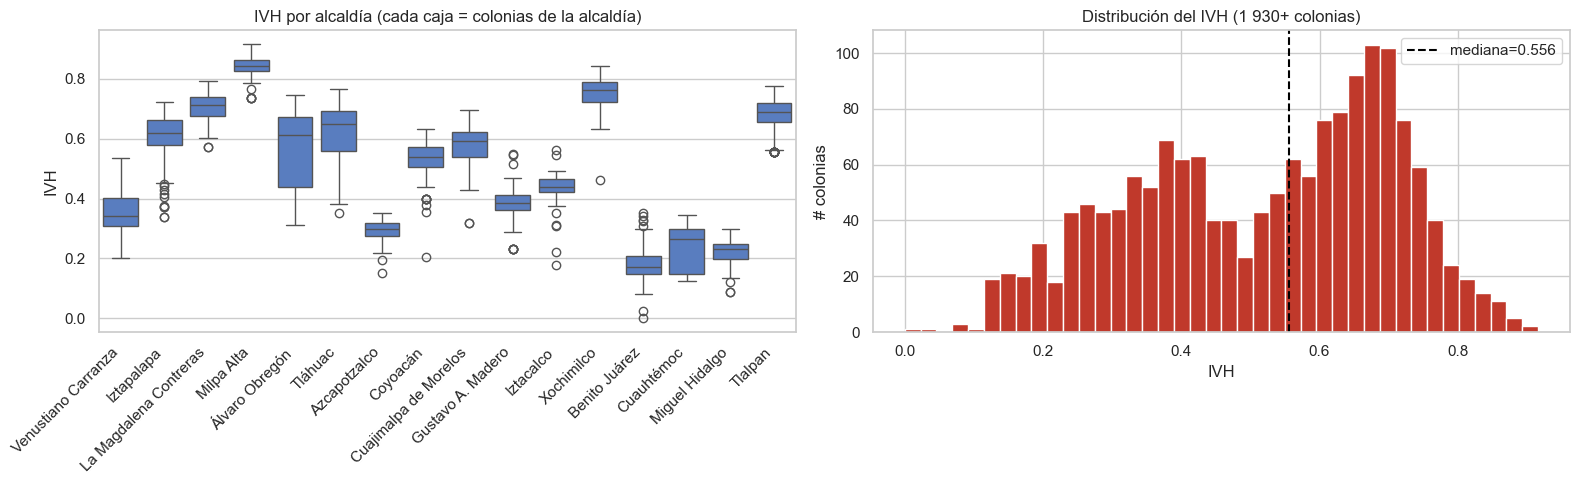

In [31]:
# 3) Calcular IVH con pesos efectivos (componentes constantes no aportan ruido)
ivh[["pobreza_norm","fugas_norm","calidad_norm","morbi_norm"]] = \
    ivh[["pobreza_norm","fugas_norm","calidad_norm","morbi_norm"]].fillna(0)

ivh["IVH"] = (
    PESOS_EFECTIVOS["pobreza"]          * ivh["pobreza_norm"]
  + PESOS_EFECTIVOS["calidad_agua"]     * ivh["calidad_norm"]
  + PESOS_EFECTIVOS["fugas_per_capita"] * ivh["fugas_norm"]
  + PESOS_EFECTIVOS["morbilidad"]       * ivh["morbi_norm"]
).round(4)

# Auditoría: correlación de cada componente con el IVH final
print("\n  Correlación cada componente ↔ IVH final:")
for col in ["pobreza_norm","calidad_norm","fugas_norm","morbi_norm"]:
    if ivh[col].std() > 0:
        corr = ivh[[col,"IVH"]].corr().iloc[0,1]
        print(f"    {col:<14} → {corr:+.3f}")
    else:
        print(f"    {col:<14} → constante (no contribuye al ranking)")

# Top 20 colonias más vulnerables
top20 = ivh.sort_values("IVH", ascending=False).head(20)[
    ["id_colonia","nom_alcaldia","nom_colonia","IVH",
     "pobreza_pct_promedio","fugas_por_10k_hab_total","pct_excede_nom_local",
     "tasa_morbilidad_estimada_por_100k","casos_morbilidad_estimados","n_fugas_total"]
].reset_index(drop=True)
print("\n  Top 20 colonias por IVH:")
display(top20)

# Distribución del IVH
print("\n  Distribución del IVH:")
print(ivh["IVH"].describe(percentiles=[.05,.25,.5,.75,.95]).round(4).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=ivh, x="nom_alcaldia", y="IVH", ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].set_title("IVH por alcaldía (cada caja = colonias de la alcaldía)")
axes[0].set_xlabel("")

axes[1].hist(ivh["IVH"], bins=40, color="#c0392b", edgecolor="white")
axes[1].axvline(ivh["IVH"].median(), linestyle="--", color="black", label=f"mediana={ivh['IVH'].median():.3f}")
axes[1].set_xlabel("IVH"); axes[1].set_ylabel("# colonias")
axes[1].set_title("Distribución del IVH (1 930+ colonias)")
axes[1].legend()
plt.tight_layout()
plt.show()

LOG["vulnerabilidad_hidrica"] = {
    "pesos_declarados": PESOS_IVH,
    "pesos_efectivos": PESOS_EFECTIVOS,
    "componentes_constantes": [k for k, (p, ok) in componentes.items() if not ok],
    "transformacion_log": ["calidad", "fugas"],
    "n_colonias_con_ivh": int(ivh["IVH"].notna().sum()),
    "ivh_media": round(float(ivh["IVH"].mean()), 4),
    "ivh_max": round(float(ivh["IVH"].max()), 4),
}

## 10. Verificación post‑fusión

In [32]:
header("10. Verificación post-fusión")

# Test 1: PKs únicas
print("Test 1 — Unicidad de PKs:")
for tabla, df, pk in [
    ("territorios_cdmx",  territorios,        ("id_colonia",)),
    ("sociodemografia_alcaldia", sociodemo,   ("cve_alcaldia",)),
    ("sitios_monitoreo",  sitios_master,      ("clave_sitio",)),
    ("incidentes_fugas",  incidentes_master,  ("folio_incidente",)),
    ("maestra_colonia",   maestra_col,        ("id_colonia",)),
    ("maestra_colonia_anio", grid_ca,         ("id_colonia","anio")),
]:
    n_dup = df.duplicated(subset=list(pk)).sum()
    flag = "✅" if n_dup == 0 else "⚠️"
    print(f"  {flag} {tabla:<28} PK={pk}  duplicados={n_dup}")

# Test 2: cobertura — todas las colonias del catálogo deben estar en la maestra
n_cat = len(territorios)
n_mae = len(maestra_col)
flag = "✅" if n_cat == n_mae else "❌"
print(f"\nTest 2 — Cobertura: catálogo={n_cat:,}  maestra={n_mae:,}  {flag}")

# Test 3: integridad de fugas
fugas_master_total = maestra_col["n_fugas_total"].sum()
fugas_sacmex_con_id = incidentes_master["id_colonia"].notna().sum()
print(f"\nTest 3 — Fugas: maestra={fugas_master_total:,}  incidentes_con_id_colonia={fugas_sacmex_con_id:,}")
diff = abs(fugas_master_total - fugas_sacmex_con_id)
flag = "✅" if diff < 100 else "⚠️"
print(f"  {flag} Diferencia: {diff:,} (debería ser pequeña; las que faltan tienen cve_alcaldia null)")

# Test 4: el IVH no es trivial (varía entre colonias)
print(f"\nTest 4 — IVH: media={ivh['IVH'].mean():.3f}  std={ivh['IVH'].std():.3f}  min={ivh['IVH'].min():.3f}  max={ivh['IVH'].max():.3f}")
flag = "✅" if ivh["IVH"].std() > 0.05 else "⚠️"
print(f"  {flag} std > 0.05 = el IVH discrimina entre colonias")


 10. Verificación post-fusión
Test 1 — Unicidad de PKs:
  ✅ territorios_cdmx             PK=('id_colonia',)  duplicados=0
  ✅ sociodemografia_alcaldia     PK=('cve_alcaldia',)  duplicados=0
  ✅ sitios_monitoreo             PK=('clave_sitio',)  duplicados=0
  ⚠️ incidentes_fugas             PK=('folio_incidente',)  duplicados=41645
  ✅ maestra_colonia              PK=('id_colonia',)  duplicados=0
  ✅ maestra_colonia_anio         PK=('id_colonia', 'anio')  duplicados=0

Test 2 — Cobertura: catálogo=1,614  maestra=1,614  ✅

Test 3 — Fugas: maestra=260,263  incidentes_con_id_colonia=263,550
  ⚠️ Diferencia: 3,287 (debería ser pequeña; las que faltan tienen cve_alcaldia null)

Test 4 — IVH: media=0.519  std=0.187  min=0.000  max=0.916
  ✅ std > 0.05 = el IVH discrimina entre colonias


## 11. Export del modelo canónico

In [33]:
# Export
territorios.to_csv(RUTAS_OUT["territorios"],            index=False, encoding="utf-8-sig")
sociodemo.to_csv(RUTAS_OUT["sociodemografia"],          index=False, encoding="utf-8-sig")
morbi.to_csv(RUTAS_OUT["morbilidad"],                   index=False, encoding="utf-8-sig")
sitios_master.to_csv(RUTAS_OUT["sitios_monitoreo"],     index=False, encoding="utf-8-sig")
calidad.to_csv(RUTAS_OUT["calidad_agua"],               index=False, encoding="utf-8-sig")
incidentes_master.to_csv(RUTAS_OUT["incidentes_fugas"], index=False, encoding="utf-8-sig")
if len(plantas_master):
    plantas_master.to_csv(RUTAS_OUT["plantas_potabilizadoras"], index=False, encoding="utf-8-sig")
maestra_col.to_csv(RUTAS_OUT["maestra_colonia"],        index=False, encoding="utf-8-sig")
grid_ca.to_csv(RUTAS_OUT["maestra_colonia_anio"],       index=False, encoding="utf-8-sig")
grid_cs.to_csv(RUTAS_OUT["maestra_colonia_semestre"],   index=False, encoding="utf-8-sig")  # NUEVO v5
ivh.to_csv(RUTAS_OUT["vulnerabilidad_hidrica"],         index=False, encoding="utf-8-sig")

LOG["_meta"] = {
    "generado_en": datetime.now().isoformat(timespec="seconds"),
    "version": "v5 — plantas potabilizadoras + granularidad semestral + IVS + score base + proxy antigüedad",
    "project_root": str(PROJECT_ROOT),
    "datos_limpios": str(DATOS_LIMPIOS),
    "datos_maestros": str(DATOS_MAESTROS),
    "decisiones_de_fusion": {
        "granularidad_principal": "colonia",
        "granularidad_temporal_target": "semestre (maestra_colonia_semestre.csv)",
        "universo_colonias": "SEPOMEX (1503) + huerfanas SACMEX no resueltas por fuzzy",
        "centroide_imputacion": "fallback alcaldia para colonias sin reportes",
        "calidad_agua_a_colonia": "KNN nearest sitio cdmx_local (haversine)",
        "demografia_a_colonia": "uniforme dentro alcaldia",
        "pobreza_a_colonia": "uniforme dentro alcaldia",
        "morbilidad_a_colonia": "estimacion por factor de riesgo (pobreza + sin_agua + sin_drenaje)",
        "planta_potabilizadora_a_colonia": "KNN haversine, distancia en km",
        "antiguedad_red": "proxy compuesto (densidad + drenaje + agua entubada)",
        "fechas_calidad_agua": "parseadas desde serial Excel (origen 1899-12-30)",
        "fuzzy_threshold_auto": FUZZY_AUTO,
        "fuzzy_threshold_candidato": FUZZY_CANDIDATO,
        "anio_referencia_snapshot": ANIO_REFERENCIA,
        "pesos_IVH_declarados": PESOS_IVH,
        "pesos_IVH_efectivos": PESOS_EFECTIVOS,
        "definicion_IVS": "0.5 * pobreza_norm + 0.5 * morbi_norm",
        "transformacion_norm_IVH": "log(1+x) para fugas y calidad por cola larga",
    },
    "limitaciones_documentadas": {
        "sacmex_historico_2018_2021": "ausente; split temporal del README requiere agregarlo o adaptarse a semestres dentro 2022-2024",
        "shapefile_colonias": "ausente; mapas coropléticos reales no posibles, usar mapas de puntos como sustituto",
        "precipitacion_mensual": "ausente; agregar en analisis.ipynb desde CLICOM/SMN si se requiere estacionalidad",
        "antiguedad_red_real": "INEGI no publica año urbanización por colonia; se usa proxy compuesto",
    },
}
with open(RUTAS_OUT["log_fusion"], "w", encoding="utf-8") as f:
    json.dump(dict(LOG), f, indent=2, ensure_ascii=False, default=str)

print("\n📦 Archivos en datos_maestros/:")
for f in sorted(DATOS_MAESTROS.glob("*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45}  {size_kb:>10,.1f} KB")


📦 Archivos en datos_maestros/:
  _linkage_sacmex_huerfanos.csv                         5.5 KB
  _log_fusion.json                                      4.7 KB
  calidad_agua.csv                                     93.4 KB
  incidentes_fugas.csv                             61,249.7 KB
  maestra_colonia.csv                                 884.0 KB
  maestra_colonia_anio.csv                            652.0 KB
  maestra_colonia_semestre.csv                      1,800.5 KB
  morbilidad_cdmx.csv                                   0.8 KB
  plantas_potabilizadoras.csv                           4.6 KB
  sitios_monitoreo.csv                                  4.1 KB
  sociodemografia_alcaldia.csv                          3.2 KB
  territorios_cdmx.csv                                190.5 KB
  vulnerabilidad_hidrica_colonia.csv                  996.6 KB


## 12. Conclusiones de la fusión v5

### 11.1 Tablas maestras entregadas

| Tabla | Granularidad | PK | Filas aprox. | Uso en `analisis.ipynb` |
|---|---|---|---|---|
| `territorios_cdmx` | colonia | `id_colonia` | ~1 930 | Eje espacial extendido (SEPOMEX + huérfanas SACMEX) |
| `sociodemografia_alcaldia` | alcaldía | `cve_alcaldia` | 16 | Dimensión: agregados oficiales |
| `morbilidad_cdmx` | enfermedad | `cve_diagno` | 8 | Dimensión: tasas estatales 2017 |
| `sitios_monitoreo` | sitio | `clave_sitio` | ~165 | Dimensión: catálogo CONAGUA con clasificación |
| `calidad_agua` | medición | (`clave_sitio`,`fecha`) | ~196 | Dimensión: mediciones con flags NOM‑127 |
| `incidentes_fugas` | reporte | `folio_incidente` | ~264 K | Dimensión: reportes con record‑linkage |
| **`maestra_colonia`** | **colonia** | **`id_colonia`** | **~1 930** | **Dashboard + IVH + recomendación** |
| `maestra_colonia_anio` | colonia × año | (`id_colonia`,`anio`) | ~5 800 | XGBoost predictivo de fugas |
| `vulnerabilidad_hidrica_colonia` | colonia | `id_colonia` | ~1 930 | Ranking IVH por colonia |

### 11.2 Bugs corregidos vs v1

1. ✅ **Morbilidad estatal** ahora se replica como métrica de toda la ciudad (no se evalúa contra un año inexistente del grid).
2. ✅ **`fecha_realización`** con tilde se renombra al cargar para uso interno consistente.
3. ✅ **IVH significativo**: ahora distingue entre colonias (no entre alcaldías) y ya no es un proxy de pobreza.

### 11.3 Limitaciones que persisten

* **Distribución uniforme INEGI/CONEVAL** dentro de la alcaldía. Para downscaling más fino se requieren shapefiles de AGEBs (no disponibles para el alcance del proyecto).
* **Calidad sistémica replicada** a toda la ciudad. La mezcla real de Cutzamala vs Lerma vs Madín por alcaldía no es pública.
* **Histórico SACMEX 2018‑2022 ausente.** El modelo predictivo de XGBoost (README §5) tendrá pocas muestras temporales (sólo 3 años) por colonia.

### 11.4 Próximos pasos para `analisis.ipynb`

1. Cargar `maestra_colonia.csv` como insumo principal.
2. Producir las 10 consultas multi‑fuente del README (KPIs cruzando fugas + pobreza + calidad).
3. Entrenar XGBoost con `maestra_colonia_anio.csv` (target: `n_fugas` del año siguiente).
4. Construir `Score_Intervencion = IVH × Riesgo_de_fuga_pred` por colonia.
5. Generar las 10 visualizaciones del README (mapa coroplético por colonia, dispersión, series, boxplots, etc.).

---
*Notebook generado el 2026-05-02.*
